In [1]:
import scanpy as sc

In [2]:
import os

direct = os.path.dirname(os.path.dirname(os.getcwd()))
raw_data_path = os.path.join(direct, "data", "raw")
samples = os.listdir(raw_data_path)
print(samples)
print(fr"Sem neural pura: {len(samples)}")

['CTH92_ML', 'CTH92_NS', 'CTH94_ML', 'CTH94_NS', 'CTH97_ML', 'CTH97_NS', 'HNP44_ML', 'HNP44_NS', 'MB34_ML', 'MB34_NS', 'PB20_ML', 'PB20_NS', 'PB21_ML', 'PB21_NS']
Sem neural pura: 14


In [ ]:
import os
import scanpy as sc

adatas = {}
for sample in samples:
    path = os.path.join(raw_data_path, sample)
    adata = sc.read_10x_mtx(
        path,
        var_names="gene_symbols",  # ou "gene_ids" se preferir usar Ensembl IDs
        cache=True
    )
    adata.obs_names_make_unique()
    adata.var_names_make_unique()
    adatas[sample] = adata
    print(f"✓ {sample}: {adata.n_obs} células, {adata.n_vars} genes")

print(f"\nTotal de amostras carregadas: {len(adatas)}")

In [37]:
adatas.keys()

dict_keys(['CTH92_ML', 'CTH92_NS', 'CTH94_ML', 'CTH94_NS', 'CTH97_ML', 'CTH97_NS', 'HNP44_ML', 'HNP44_NS', 'MB34_ML', 'MB34_NS', 'PB20_ML', 'PB20_NS', 'PB21_ML', 'PB21_NS'])

In [38]:
list(adatas.keys())[0]

'CTH92_ML'

In [39]:
for key in adatas:
    adata = adatas[key]
    adata.write_h5ad(os.path.join(direct, "data", "raw_h5ad", f"{key}.h5ad"))

In [40]:
path_to_adatas = os.path.join(direct, "data", "raw_h5ad")
adatas_list = [sc.read(os.path.join(path_to_adatas, adata_name)) for adata_name in os.listdir(path_to_adatas)]

In [41]:
names = [adata_name.split(".")[0] for adata_name in os.listdir(path_to_adatas)]

In [42]:
names

['CTH92_ML',
 'CTH92_NS',
 'CTH94_ML',
 'CTH94_NS',
 'CTH97_ML',
 'CTH97_NS',
 'HNP44_ML',
 'HNP44_NS',
 'MB34_ML',
 'MB34_NS',
 'PB20_ML',
 'PB20_NS',
 'PB21_ML',
 'PB21_NS']

In [43]:
adatas_list

[AnnData object with n_obs × n_vars = 1562 × 38606
     var: 'gene_ids', 'feature_types',
 AnnData object with n_obs × n_vars = 847 × 38606
     var: 'gene_ids', 'feature_types',
 AnnData object with n_obs × n_vars = 546 × 38606
     var: 'gene_ids', 'feature_types',
 AnnData object with n_obs × n_vars = 5981 × 38606
     var: 'gene_ids', 'feature_types',
 AnnData object with n_obs × n_vars = 4695 × 38606
     var: 'gene_ids', 'feature_types',
 AnnData object with n_obs × n_vars = 1603 × 38606
     var: 'gene_ids', 'feature_types',
 AnnData object with n_obs × n_vars = 2043 × 38606
     var: 'gene_ids', 'feature_types',
 AnnData object with n_obs × n_vars = 108 × 38606
     var: 'gene_ids', 'feature_types',
 AnnData object with n_obs × n_vars = 999 × 38606
     var: 'gene_ids', 'feature_types',
 AnnData object with n_obs × n_vars = 2136 × 38606
     var: 'gene_ids', 'feature_types',
 AnnData object with n_obs × n_vars = 838 × 38606
     var: 'gene_ids', 'feature_types',
 AnnData object

In [44]:
import spatools as st
import scanpy as sc
import os
import sys

def readData():
    while True:
        try:
            adatas: dict = st.read(os.path.join(direct, "data", "raw_h5ad"))# type: ignore
            return adatas
        except:
            os.chdir("../../")
adatas = readData()

🔎 Analisando diretório: /mnt/SATA/singleCellTaru/data/raw_h5ad
  ➜ Processando: 'CTH92_ML.h5ad' ... ✅ Lido como [H5AD]
  ➜ Processando: 'CTH92_NS.h5ad' ... ✅ Lido como [H5AD]
  ➜ Processando: 'CTH94_ML.h5ad' ... ✅ Lido como [H5AD]
  ➜ Processando: 'CTH94_NS.h5ad' ... ✅ Lido como [H5AD]
  ➜ Processando: 'CTH97_ML.h5ad' ... ✅ Lido como [H5AD]
  ➜ Processando: 'CTH97_NS.h5ad' ... ✅ Lido como [H5AD]
  ➜ Processando: 'HNP44_ML.h5ad' ... ✅ Lido como [H5AD]
  ➜ Processando: 'HNP44_NS.h5ad' ... ✅ Lido como [H5AD]
  ➜ Processando: 'MB34_ML.h5ad' ... ✅ Lido como [H5AD]
  ➜ Processando: 'MB34_NS.h5ad' ... ✅ Lido como [H5AD]
  ➜ Processando: 'PB20_ML.h5ad' ... ✅ Lido como [H5AD]
  ➜ Processando: 'PB20_NS.h5ad' ... ✅ Lido como [H5AD]
  ➜ Processando: 'PB21_ML.h5ad' ... ✅ Lido como [H5AD]
  ➜ Processando: 'PB21_NS.h5ad' ... ✅ Lido como [H5AD]


In [ ]:
from copy import deepcopy
adatas_raw = deepcopy(adatas)

In [46]:
adatas["CTH92_ML"].var

,gene_ids,feature_types,n_cells
ENSG00000238009,ENSG00000238009,Gene Expression,3
ENSG00000239945,ENSG00000239945,Gene Expression,1
ENSG00000241860,ENSG00000241860,Gene Expression,13
ENSG00000290385,ENSG00000290385,Gene Expression,10
ENSG00000291215,ENSG00000291215,Gene Expression,39
...,...,...,...
MAFIP,ENSG00000274847,Gene Expression,12
ENSG00000278384,ENSG00000278384,Gene Expression,31
ENSG00000273748,ENSG00000273748,Gene Expression,36
ENSG00000271254,ENSG00000271254,Gene Expression,28


In [47]:
import spatools as st

adatas = st.pp.Preprocessing.run("MAD_combined", adatas_dict=adatas, k=5) # TODO change k value in your analysis

In [48]:
print(f"Spots antes {sum([adatas_raw[i].n_obs for i in adatas])}, genes antes {sum([adatas_raw[i].n_vars for i in adatas])}")

print(f"Spots depois {sum([adatas[i].n_obs for i in adatas])}, genes depois {sum([adatas[i].n_vars for i in adatas])}")

print("\n")

print(f"Corte de spots após filtro: {round(1-sum([adatas[i].n_obs for i in adatas])/sum([adatas_raw[i].n_obs for i in adatas]), 2)}%")

Spots antes 37161, genes antes 362636
Spots depois 34969, genes depois 361445


Corte de spots após filtro: 0.06%


In [49]:
import matplotlib.pyplot as plt
from typing import Optional
import pandas as pd
import numpy as np


def preprocessing_quality_metrics(
    adatas: dict,
    title: str = "Quality Metrics: Aggregate (Top) and Individual (Bottom)",
    xlabel: str = "Filtering Stages",
    ylabel_top: str = "Total Sum",
    ylabel_bottom: str = "Spots per Sample",
    x_labels: list = ["A\n(Raw)", "B\n(Counts & Genes)", "C\n(MT Filter)"],
    legend_title_bottom: str = "Samples",
    legend_label_top: str = "Total Sum",
    figsize: tuple = (12, 9),
    save_path=None,
    font_size_base: int = 18,
    colors: Optional[list] = None,
    dodge: float = 0.02
):
    """
    Quality plot for preprocessing using st.pp.Preprocessing.run
    """

    # ---------------------------------------------------------
    # 1. Data Extraction
    # ---------------------------------------------------------
    adatas_list = list(adatas.values()) if isinstance(adatas, dict) else adatas

    if colors is None:
        colors = list(
            plt.get_cmap("tab20")(
                np.linspace(0, 1, len(adatas_list))
            )
        )

    all_values = []
    sample_names = []

    for adata in adatas_list:

        stats_key = next(
            (k for k in adata.uns.keys()
             if k.startswith("preprocessing_stats_")),
            None
        )

        if stats_key is None:
            continue

        stats = adata.uns[stats_key]

        values = [
            stats.get("initial_n_spots", np.nan),
            stats.get("n_after_combined_filter", np.nan),
            stats.get("n_after_mt_filter", np.nan),
            stats.get("n_after_additional_filter", np.nan)
        ]

        all_values.append(values)

        sample_names.append(
            stats.get("sample_id", "Unknown")
        )

    # converter para array float
    all_values = np.array(all_values, dtype=float)

    # ---------------------------------------------------------
    # Remove colunas totalmente NaN
    # ---------------------------------------------------------
    default_x_labels = np.array([
        "A\n(Raw)",
        "B\n(Counts & Genes)",
        "C\n(MT Filter)",
        "D\n(Additional)"
    ])

    valid_cols = ~np.all(np.isnan(all_values), axis=0)

    all_values = all_values[:, valid_cols]

    columns = np.array([
        "Raw",
        "Counts&Genes",
        "MT",
        "Additional"
    ])[valid_cols]

    # garantir tamanho correto
    if len(x_labels) != len(default_x_labels):
        x_labels = default_x_labels# type: ignore

    x_labels = np.array(x_labels)[valid_cols]# type: ignore

    # ---------------------------------------------------------
    # DataFrame
    # ---------------------------------------------------------
    df = pd.DataFrame(
        all_values,
        columns=columns,
        index=sample_names
    )

    step_sums = df.sum(axis=0)

    # ---------------------------------------------------------
    # 2. Figure Setup
    # ---------------------------------------------------------
    plt.rcParams.update({'font.size': font_size_base})

    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        sharex=True,
        figsize=figsize,
        gridspec_kw={'height_ratios': [1, 2.5]}
    )

    fig.subplots_adjust(hspace=0.1)

    # ---------------------------------------------------------
    # Upper Axis (Aggregate)
    # ---------------------------------------------------------
    ax1.plot(
        x_labels,
        step_sums,
        marker="D",
        ls="-",
        color="darkred",
        lw=3,
        ms=10,
        label=legend_label_top
    )

    for i, val in enumerate(step_sums):

        is_last = i == len(step_sums) - 1

        ax1.text(
            i,
            val + (val * dodge) if is_last else val - (val * dodge),
            f"{int(val)}",
            ha="center",
            va="bottom",
            fontweight="bold",
            color="darkred",
            fontsize=font_size_base
        )

        if i > 0:

            prev_val = step_sums.iloc[i - 1]

            loss_pct = (
                (val - prev_val) / prev_val
            ) * 100

            mid_x = i - 0.5
            mid_y = (val + prev_val) / 2

            ax1.text(
                mid_x,
                mid_y,
                f"{loss_pct:.2f}%",
                ha="center",
                va="bottom",
                bbox=dict(
                    facecolor='white',
                    alpha=0.7,
                    edgecolor='none',
                    boxstyle='round,pad=0.2'
                ),
                color="red",
                fontweight="bold",
                fontsize=font_size_base
            )

    ax1.set_title(
        title,
        fontsize=font_size_base + 2,
        pad=20,
        fontweight="bold"
    )

    ax1.set_ylabel(
        ylabel_top,
        fontweight="bold",
        fontsize=font_size_base + 1
    )

    ax1.legend(
        loc="upper right",
        fontsize=font_size_base
    )

    y_min1, y_max1 = ax1.get_ylim()

    ax1.set_ylim(y_min1, y_max1 * 1.08)

    # ---------------------------------------------------------
    # Lower Axis (Individual)
    # ---------------------------------------------------------
    for i in range(all_values.shape[0]):

        ax2.plot(
            x_labels,
            all_values[i],
            marker=".",
            ls="-",
            alpha=0.6,
            color=colors[i],
            label=sample_names[i]
        )

    ax2.set_xlabel(
        xlabel,
        fontweight="bold",
        fontsize=font_size_base + 1
    )

    ax2.set_ylabel(
        ylabel_bottom,
        fontweight="bold",
        fontsize=font_size_base + 1
    )

    # ---------------------------------------------------------
    # Legend formatting
    # ---------------------------------------------------------
    if len(adatas) <= 10:
        ncol = 1
    elif len(adatas) <= 20:
        ncol = 2
    else:
        ncol = 3

    ax2.legend(
        title=legend_title_bottom,
        ncol=ncol,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=font_size_base - 2,
        title_fontsize=font_size_base
    )

    # ---------------------------------------------------------
    # Aesthetics
    # ---------------------------------------------------------
    ax1.spines['bottom'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    ax1.tick_params(
        labeltop=False,
        bottom=False,
        labelsize=font_size_base
    )

    ax2.tick_params(
        labelsize=font_size_base
    )

    ax1.axhline(
        ax1.get_ylim()[0],
        color='black',
        ls=':',
        lw=1
    )

    ax2.axhline(
        ax2.get_ylim()[1],
        color='black',
        ls=':',
        lw=1
    )

    d = .012

    kwargs = dict(
        transform=ax1.transAxes,
        color='black',
        clip_on=False,
        lw=2
    )

    ax1.plot((-d, +d), (-d, +d), **kwargs)
    ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)

    kwargs.update(transform=ax2.transAxes)

    ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

    # ---------------------------------------------------------
    # Save
    # ---------------------------------------------------------
    if save_path:

        plt.savefig(
            save_path,
            bbox_inches='tight',
            dpi=200
        )

        print(f"✅ Figure saved to: {save_path}")

    plt.show()

    return df

In [50]:
for name in adatas.keys():

    adata = adatas[name]

    # criar coluna booleana
    adata.obs["mt_outlier"] = (
        adata.obs["pct_counts_mt"] > 8
    )

    # número de spots após filtro adicional
    n_after_additional_filter = (
        (~adata.obs["mt_outlier"]).sum()
    )

    # adicionar ao dicionário
    adata.uns[f"preprocessing_stats_{name}"][
        "n_after_additional_filter"
    ] = int(n_after_additional_filter)
    

In [51]:
adatas["CTH92_ML"].uns["preprocessing_stats_CTH92_ML"]

{'sample_id': 'CTH92_ML',
 'initial_n_spots': 1562,
 'initial_n_genes': 24352,
 'n_after_combined_filter': 1562,
 'n_after_mt_filter': 1527,
 'final_n_spots': 1527,
 'final_n_genes': 24293,
 'n_after_additional_filter': 1527}

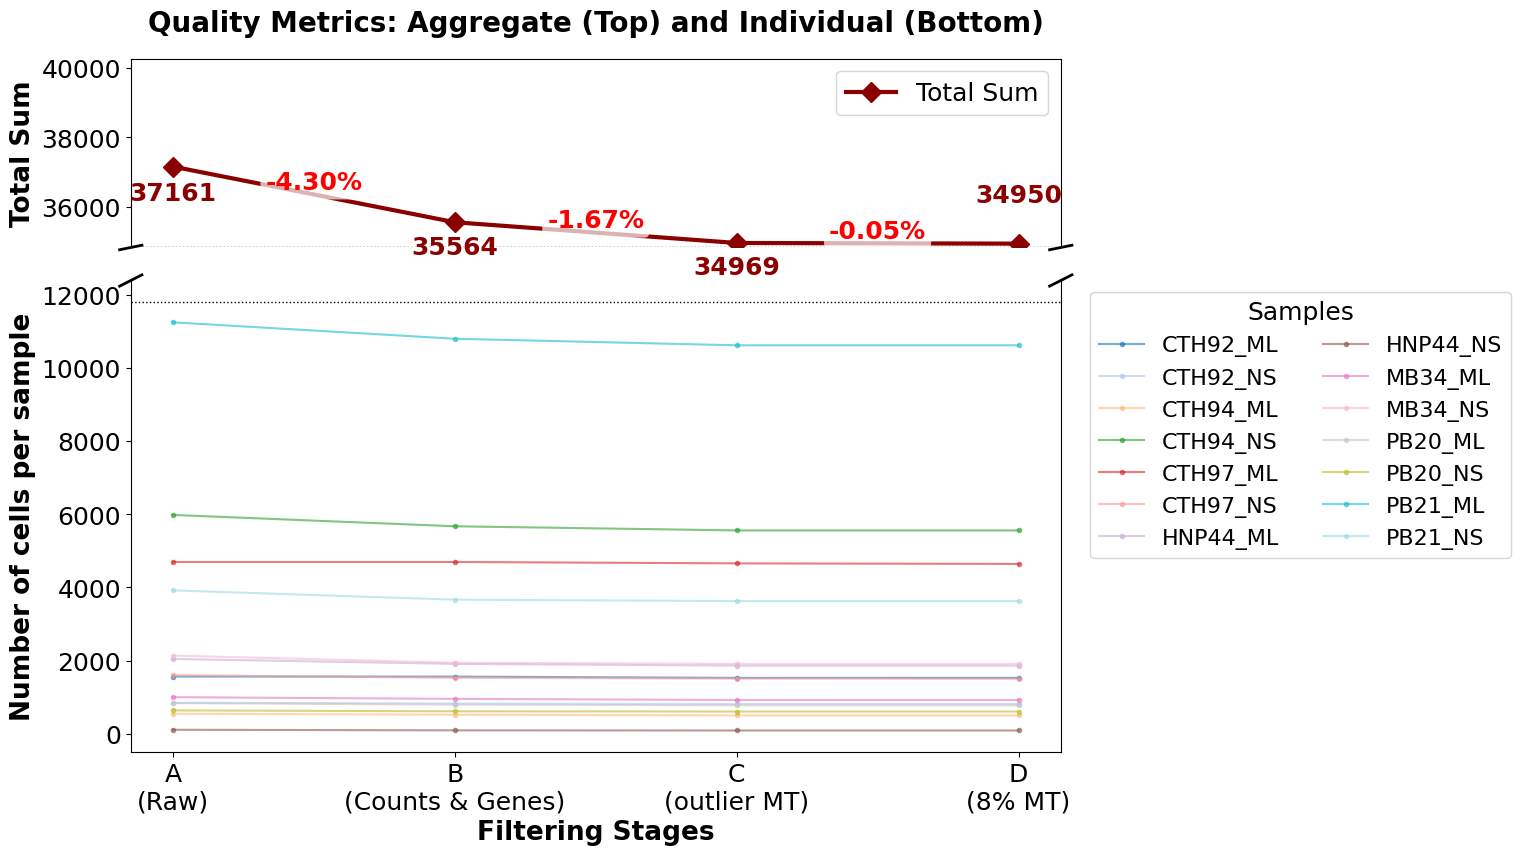

,Raw,Counts&Genes,MT,Additional
CTH92_ML,1562.0,1562.0,1527.0,1527.0
CTH92_NS,847.0,825.0,812.0,812.0
CTH94_ML,546.0,520.0,499.0,499.0
CTH94_NS,5981.0,5671.0,5558.0,5558.0
CTH97_ML,4695.0,4695.0,4657.0,4642.0
CTH97_NS,1603.0,1528.0,1506.0,1502.0
HNP44_ML,2043.0,1909.0,1862.0,1862.0
HNP44_NS,108.0,92.0,88.0,88.0
MB34_ML,999.0,953.0,921.0,921.0
MB34_NS,2136.0,1940.0,1911.0,1911.0


In [ ]:
preprocessing_quality_metrics(adatas=adatas, 
                              dodge=0.03, 
                              ylabel_bottom="Number of cells per sample", 
                              x_labels=["A\n(Raw)", "B\n(Counts & Genes)", "C\n(outlier MT)", "D\n(8% MT)"])

In [53]:
adatas.keys()

dict_keys(['CTH92_ML', 'CTH92_NS', 'CTH94_ML', 'CTH94_NS', 'CTH97_ML', 'CTH97_NS', 'HNP44_ML', 'HNP44_NS', 'MB34_ML', 'MB34_NS', 'PB20_ML', 'PB20_NS', 'PB21_ML', 'PB21_NS'])

In [54]:
for i in adatas.keys():
    adatas[i].var_names_make_unique()
    adatas[i].obs_names_make_unique()

In [55]:
[i for i in adatas["CTH92_ML"].var["mt"] if i]

[True, True, True, True, True, True, True, True, True, True, True, True, True]

In [56]:
adatas["CTH92_ML"]

AnnData object with n_obs × n_vars = 1527 × 24293
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'mt_outlier'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'preprocessing_stats_CTH92_ML'

In [ ]:
import matplotlib.pyplot as plt
import spatools as st


# Define the parameters for the plots
plot_configs = [
    {
        "clusters_col": "log1p_total_counts",
        "title": "Number of reads per spot in different samples",
        "ylabel": "log1p of number of reads",
        "legend_pos1": (0.72, 0.25),
        "legend_pos2": (0.88, 0.25),
        "outlier_type": "lower"
    },
    {
        "clusters_col": "log1p_n_genes_by_counts",
        "title": "Number of genes per spot in different samples",
        "ylabel": "log1p of number of genes",
        "legend_pos1": (0.72, 0.25),
        "legend_pos2": (0.88, 0.25),
        "outlier_type": "lower"
    },
    {
        "clusters_col": "pct_counts_mt",
        "title": "Percentage of mitochondrial genes per spot in different samples",
        "ylabel": "Percentage of expressed mitochondrial genes",
        "legend_pos1": (0.57, 0.85), # TODO
        "legend_pos2": (0.75, 0.85), # TODO
        "outlier_type": "upper"
    }
]

# Create subplots
fig, axes = plt.subplots(1, len(plot_configs), figsize=(12 * len(plot_configs), 8))

# Ensure axes is always iterable
if len(plot_configs) == 1:
    axes = [axes]

classification_dict = {
    "ML": ["Stimulated", 'deepskyblue'],
    "NS": ["Non-stimulated", 'coral']
}

# Iterate over the configurations and plot each
output_dir = os.path.join(os.getcwd(), "data", "raw" \
"" \
"_h5ad") # MAD de 5
for ax, config in zip(axes, plot_configs):
    st.pl.outlier_quality( # TODO adicionar corte dos 8%
        path_to_directory=output_dir,
        clusters_col=config["clusters_col"],
        group_by="response",
        outlier=5,
        outlier_type=config["outlier_type"],
        add_line=True,
        add_outliers=True,
        legend1_pos=config["legend_pos1"],
        legend2_pos=config["legend_pos2"],
        title=config["title"],
        ylabel=config["ylabel"],
        xlabel="Samples",
        ax=ax,  # Explicitly pass the axis to the function
        show = False,  # Prevent the function from calling plt.show()
        **classification_dict# type: ignore
    )

plt.tight_layout()
plt.show()

In [58]:
def correct_collumns(adatas):
    for key in adatas:
        adata = adatas[key]
        if not adata.var["gene_ids"].iloc[0].startswith("ENS"):
            print(adata.var)
            break
        adata.var["gene_symbols"] = adata.var.index
        adata.var.index = adata.var["gene_ids"]
        adatas[key] = adata.copy()
    return adatas
adatas = correct_collumns(adatas=adatas)

In [59]:
adatas.keys()

dict_keys(['CTH92_ML', 'CTH92_NS', 'CTH94_ML', 'CTH94_NS', 'CTH97_ML', 'CTH97_NS', 'HNP44_ML', 'HNP44_NS', 'MB34_ML', 'MB34_NS', 'PB20_ML', 'PB20_NS', 'PB21_ML', 'PB21_NS'])

In [60]:
adatas["CTH92_ML"].var

,gene_ids,feature_types,n_cells,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,gene_symbols
gene_ids,,,,,,,,,,,
ENSG00000238009,ENSG00000238009,Gene Expression,3,False,3,0.001921,0.001919,99.807939,3.0,1.386294,ENSG00000238009
ENSG00000239945,ENSG00000239945,Gene Expression,1,False,1,0.000640,0.000640,99.935980,1.0,0.693147,ENSG00000239945
ENSG00000241860,ENSG00000241860,Gene Expression,13,False,13,0.008323,0.008288,99.167734,13.0,2.639057,ENSG00000241860
ENSG00000290385,ENSG00000290385,Gene Expression,10,False,10,0.006402,0.006382,99.359795,10.0,2.397895,ENSG00000290385
ENSG00000291215,ENSG00000291215,Gene Expression,39,False,39,0.027529,0.027157,97.503201,43.0,3.784190,ENSG00000291215
...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000274847,ENSG00000274847,Gene Expression,12,False,12,0.007682,0.007653,99.231754,12.0,2.564949,MAFIP
ENSG00000278384,ENSG00000278384,Gene Expression,31,False,31,0.021767,0.021533,98.015365,34.0,3.555348,ENSG00000278384
ENSG00000273748,ENSG00000273748,Gene Expression,36,False,36,0.028169,0.027780,97.695262,44.0,3.806663,ENSG00000273748


In [61]:
adata

AnnData object with n_obs × n_vars = 3626 × 27795
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'mt_outlier'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'gene_symbols'
    uns: 'preprocessing_stats_PB21_NS'

In [62]:
output_dir = os.path.join(direct, "data", "filtered_h5ad") # MAD de 5

for name in adatas.keys():
    adata = adatas[name]
    if name.endswith(".h5ad"):
        output_file_path = os.path.join(output_dir, name)
    else:
        output_file_path = os.path.join(output_dir, f"{name}.h5ad")

    sc.write(output_file_path, adata)  # type: ignore

# Doublet finder

In [1]:
import scanpy as sc
import os
notebookPath = os.path.dirname(os.path.dirname(os.getcwd()))
output_dir = os.path.join(notebookPath, "data", "filtered_h5ad")
pastas = sorted(os.listdir(output_dir))

adatas = [sc.read_h5ad(os.path.join(output_dir, pastas[i])) for i in range(len(pastas))]


  Amostra: CTH92_ML.h5ad
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.36
Detected doublet rate = 0.3%
Estimated detectable doublet fraction = 0.2%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 160.0%
Elapsed time: 1.0 seconds
Threshold automático do Scrublet : 0.358
Dupletos detectados              : 4 (0.3% das células)


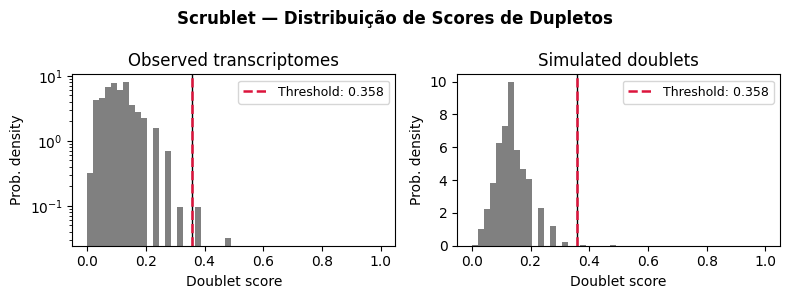

[PCA] Calculando PCA com n_comps=50...


/tmp/ipykernel_57614/2035270973.py:239: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


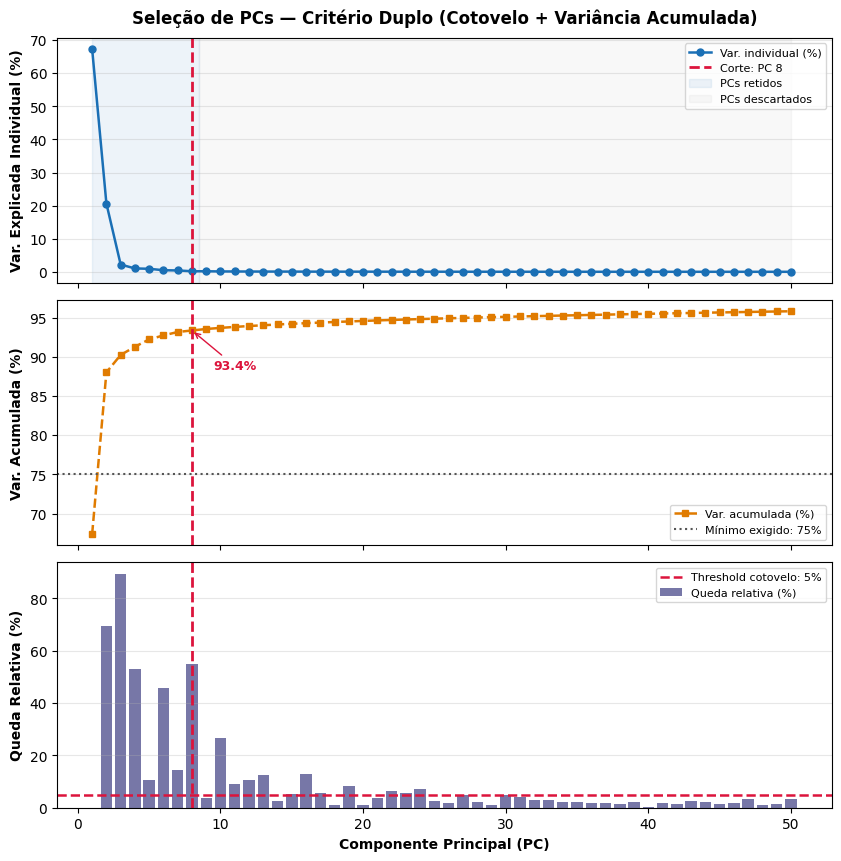


[PCA] Critério de corte : cotovelo (3.6% < 5%) + acumulada (93.4% ≥ 75%)
[PCA] PCs selecionados  : 8
[PCA] Variância capturada: 93.4%

[PCA] Recalculando PCA final com n_comps=8...


/mnt/SATA/singleCellTaru/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


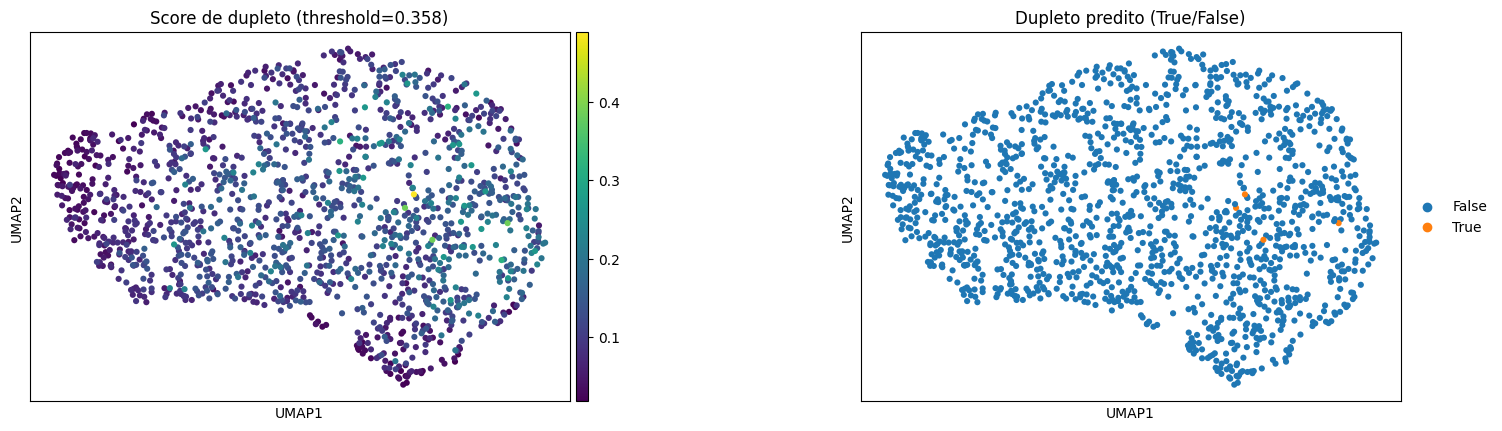


[Filtro] 4 dupletos removidos (0.3% das 1527 células).
[Filtro] 1523 células restantes.

  Amostra: CTH92_NS.h5ad
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.36
Detected doublet rate = 0.4%
Estimated detectable doublet fraction = 0.6%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 60.0%
Elapsed time: 0.6 seconds
Threshold automático do Scrublet : 0.363
Dupletos detectados              : 3 (0.4% das células)


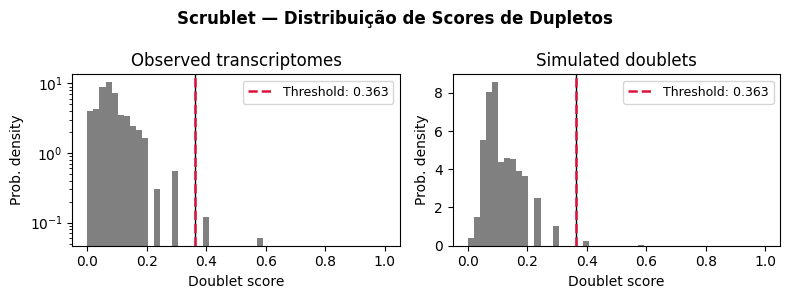

[PCA] Calculando PCA com n_comps=50...


/tmp/ipykernel_57614/2035270973.py:239: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


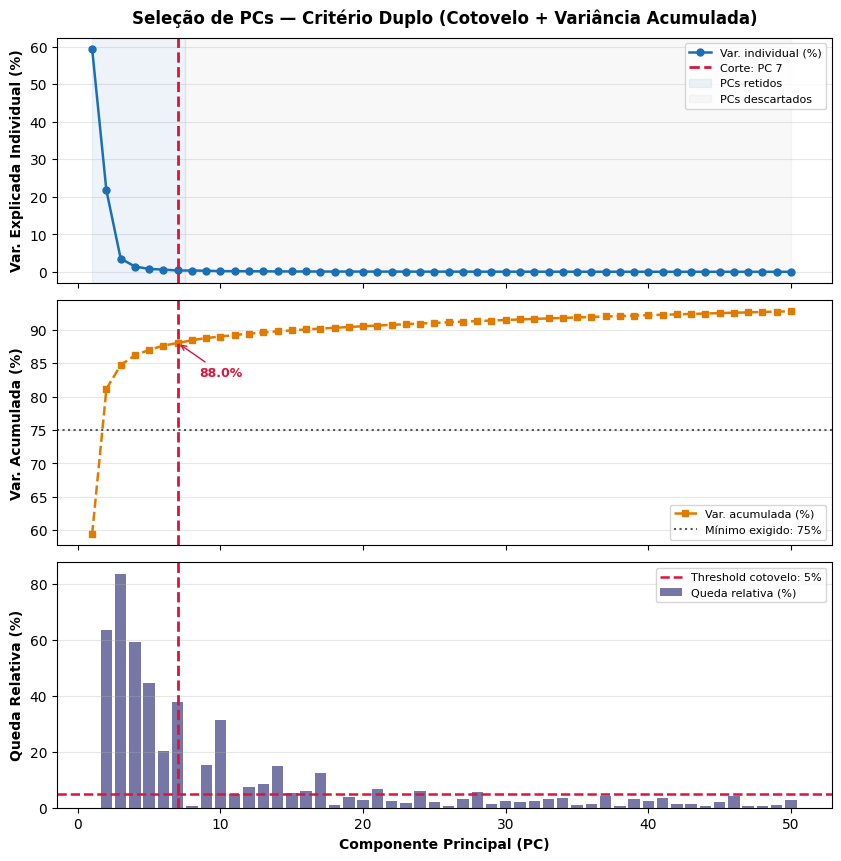


[PCA] Critério de corte : cotovelo (0.7% < 5%) + acumulada (88.0% ≥ 75%)
[PCA] PCs selecionados  : 7
[PCA] Variância capturada: 88.0%

[PCA] Recalculando PCA final com n_comps=7...


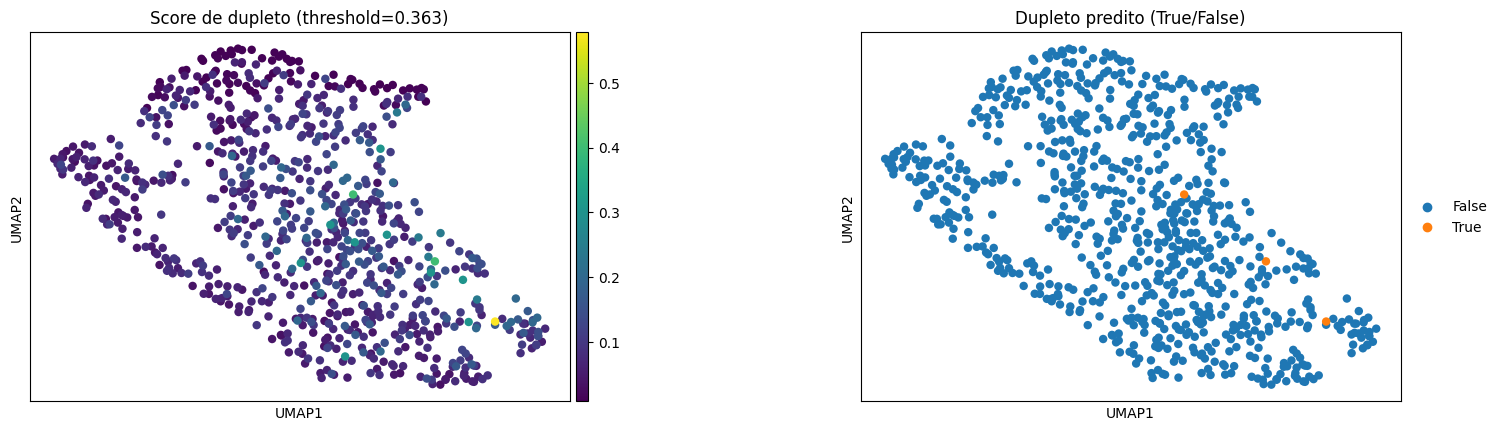


[Filtro] 3 dupletos removidos (0.4% das 812 células).
[Filtro] 809 células restantes.

  Amostra: CTH94_ML.h5ad
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.31
Detected doublet rate = 0.6%
Estimated detectable doublet fraction = 1.7%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 35.3%
Elapsed time: 0.5 seconds
Threshold automático do Scrublet : 0.307
Dupletos detectados              : 3 (0.6% das células)


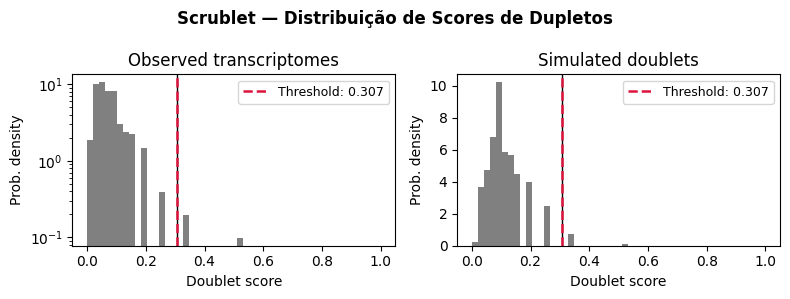

[PCA] Calculando PCA com n_comps=50...


/tmp/ipykernel_57614/2035270973.py:239: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


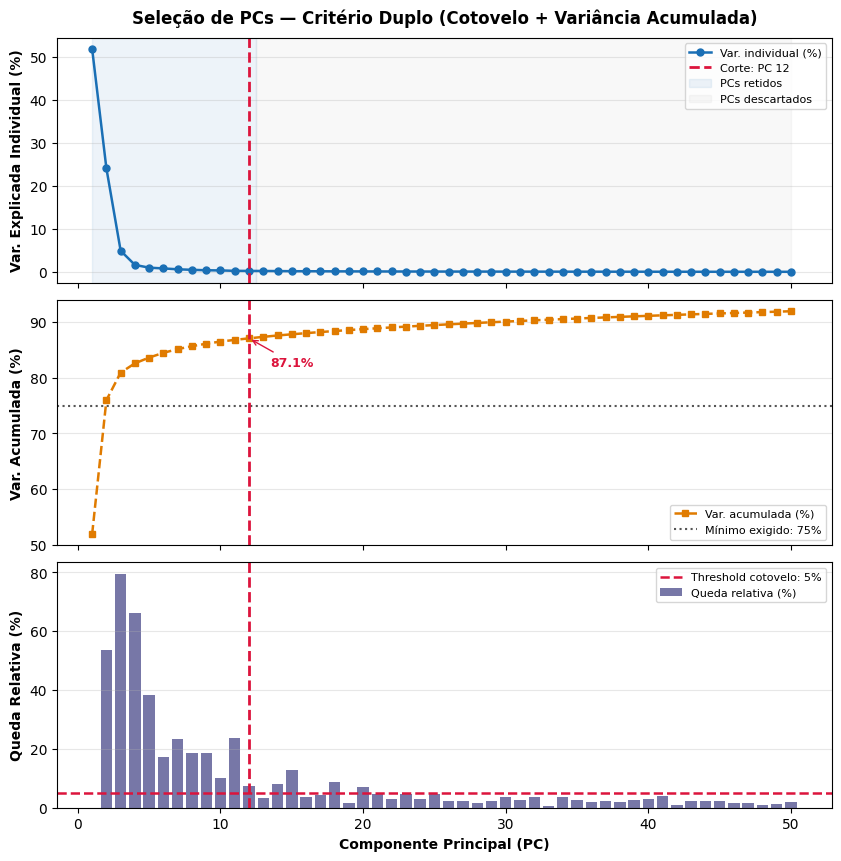


[PCA] Critério de corte : cotovelo (3.5% < 5%) + acumulada (87.1% ≥ 75%)
[PCA] PCs selecionados  : 12
[PCA] Variância capturada: 87.1%

[PCA] Recalculando PCA final com n_comps=12...


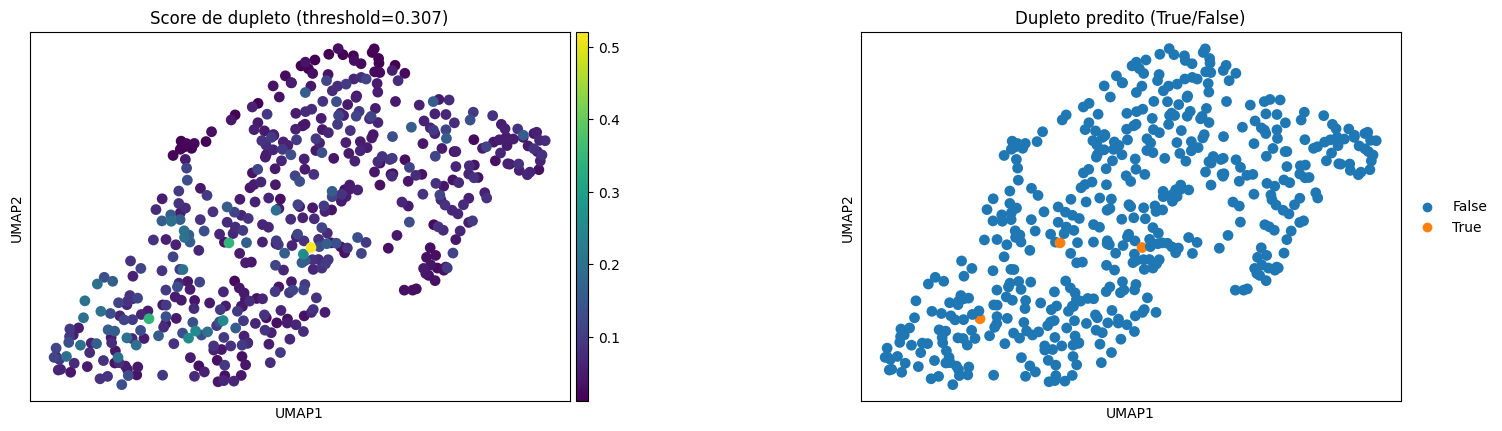


[Filtro] 3 dupletos removidos (0.6% das 499 células).
[Filtro] 496 células restantes.

  Amostra: CTH94_NS.h5ad
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.60
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.7%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 0.0%
Elapsed time: 5.0 seconds
Threshold automático do Scrublet : 0.600
Dupletos detectados              : 0 (0.0% das células)


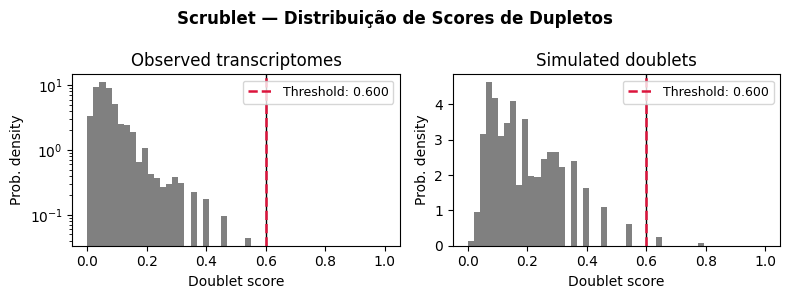

[PCA] Calculando PCA com n_comps=50...


/tmp/ipykernel_57614/2035270973.py:239: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


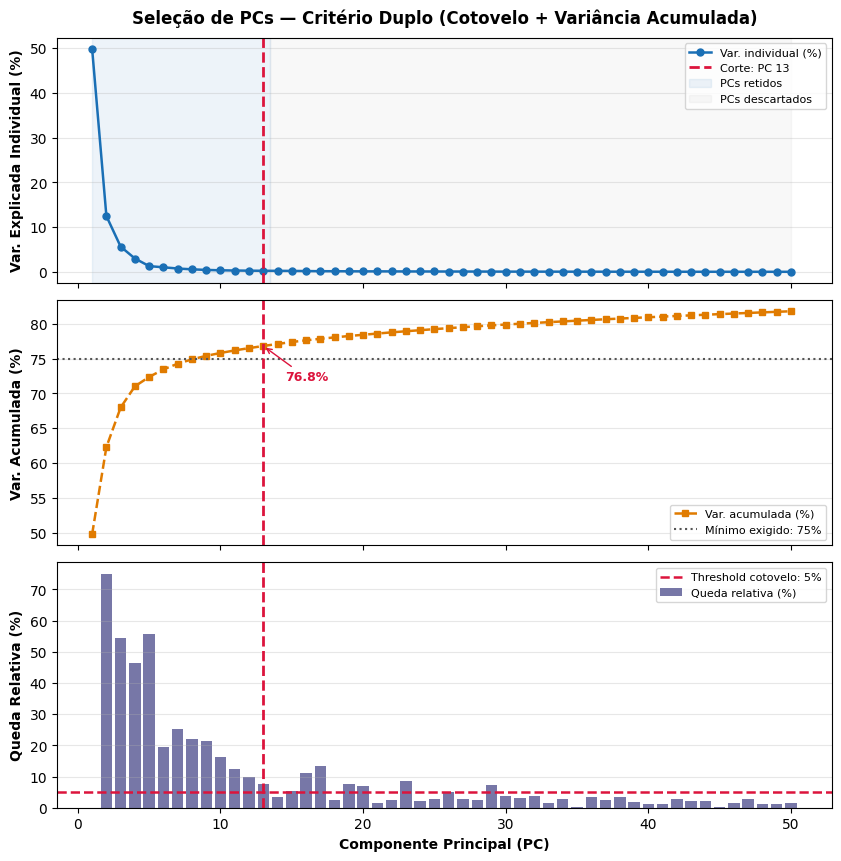


[PCA] Critério de corte : cotovelo (3.6% < 5%) + acumulada (76.8% ≥ 75%)
[PCA] PCs selecionados  : 13
[PCA] Variância capturada: 76.8%

[PCA] Recalculando PCA final com n_comps=13...


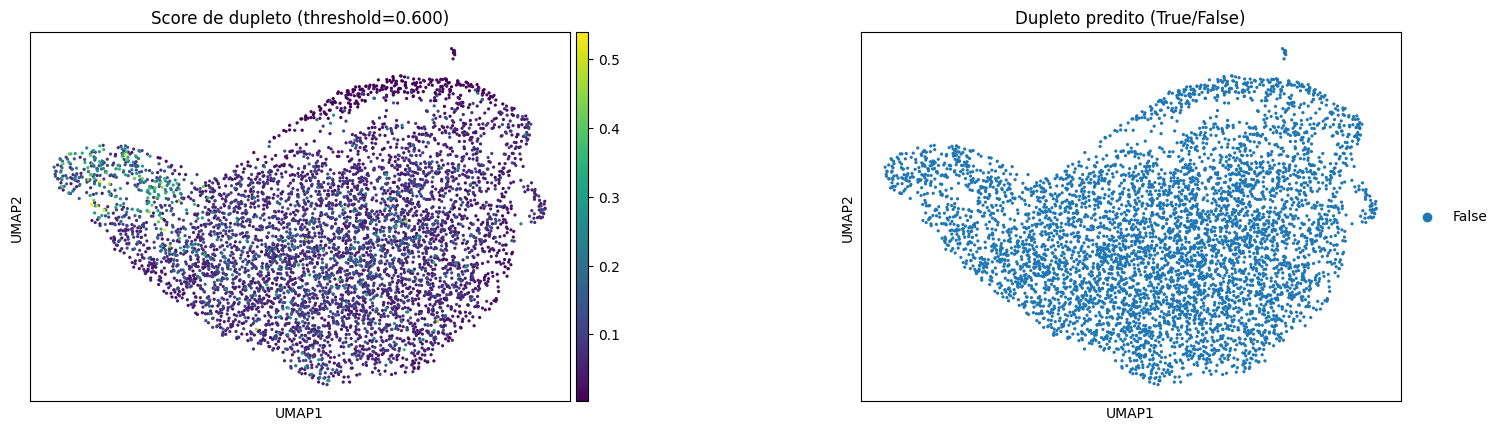


[Filtro] 0 dupletos removidos (0.0% das 5558 células).
[Filtro] 5558 células restantes.

  Amostra: CTH97_ML.h5ad
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.57
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.2%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 0.0%
Elapsed time: 2.6 seconds
Threshold automático do Scrublet : 0.574
Dupletos detectados              : 0 (0.0% das células)


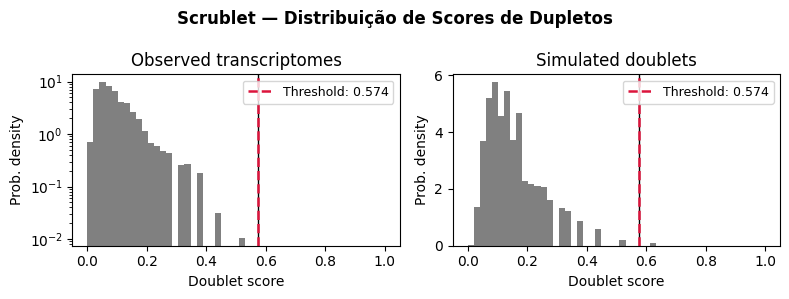

[PCA] Calculando PCA com n_comps=50...


/tmp/ipykernel_57614/2035270973.py:239: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


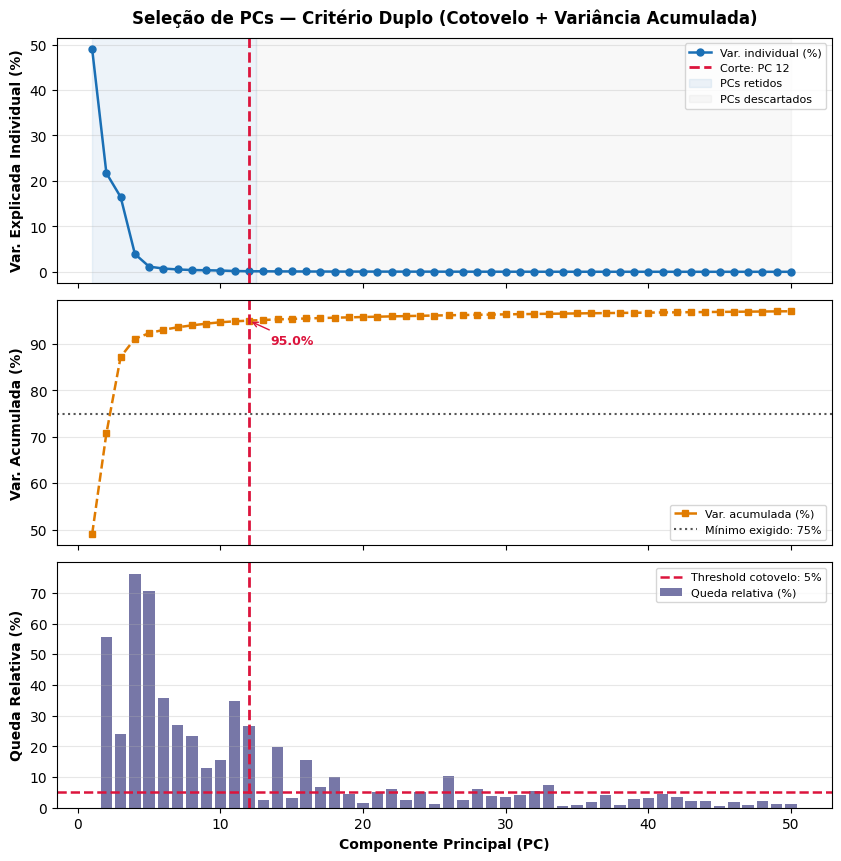


[PCA] Critério de corte : cotovelo (2.5% < 5%) + acumulada (95.0% ≥ 75%)
[PCA] PCs selecionados  : 12
[PCA] Variância capturada: 95.0%

[PCA] Recalculando PCA final com n_comps=12...


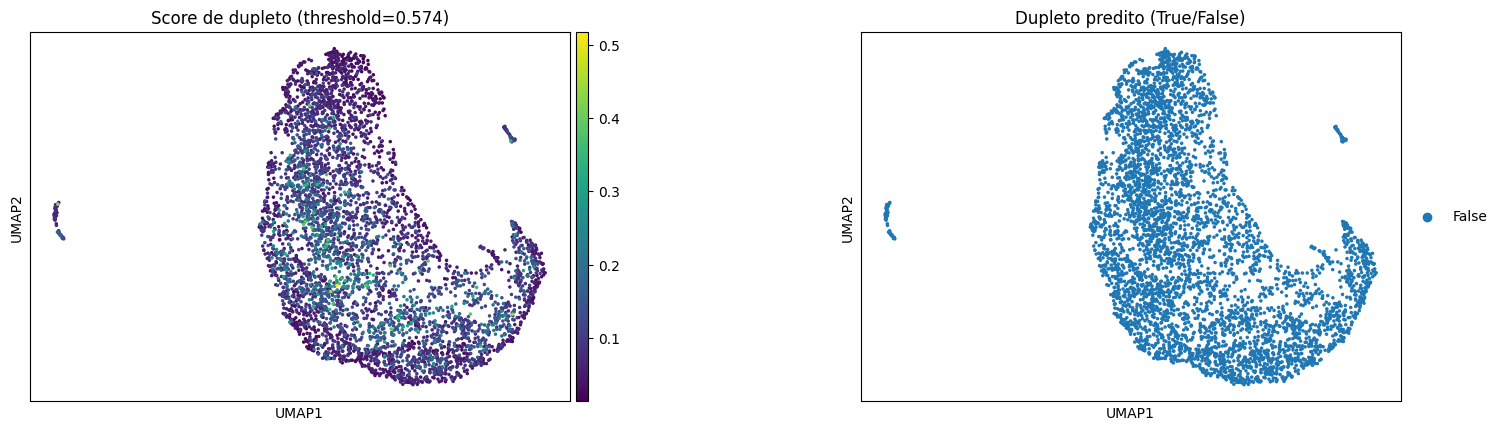


[Filtro] 0 dupletos removidos (0.0% das 4657 células).
[Filtro] 4657 células restantes.

  Amostra: CTH97_NS.h5ad
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.43
Detected doublet rate = 0.3%
Estimated detectable doublet fraction = 2.1%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 12.5%
Elapsed time: 1.0 seconds
Threshold automático do Scrublet : 0.431
Dupletos detectados              : 4 (0.3% das células)


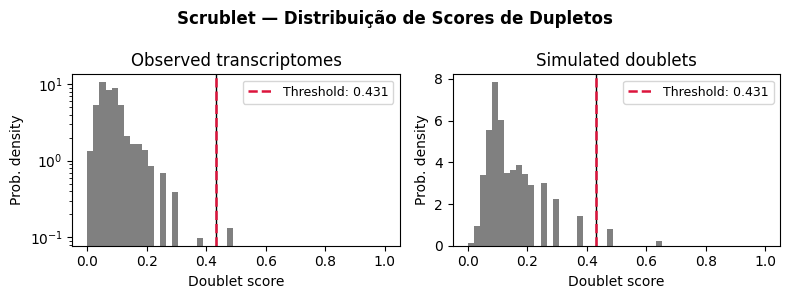

[PCA] Calculando PCA com n_comps=50...


/tmp/ipykernel_57614/2035270973.py:239: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


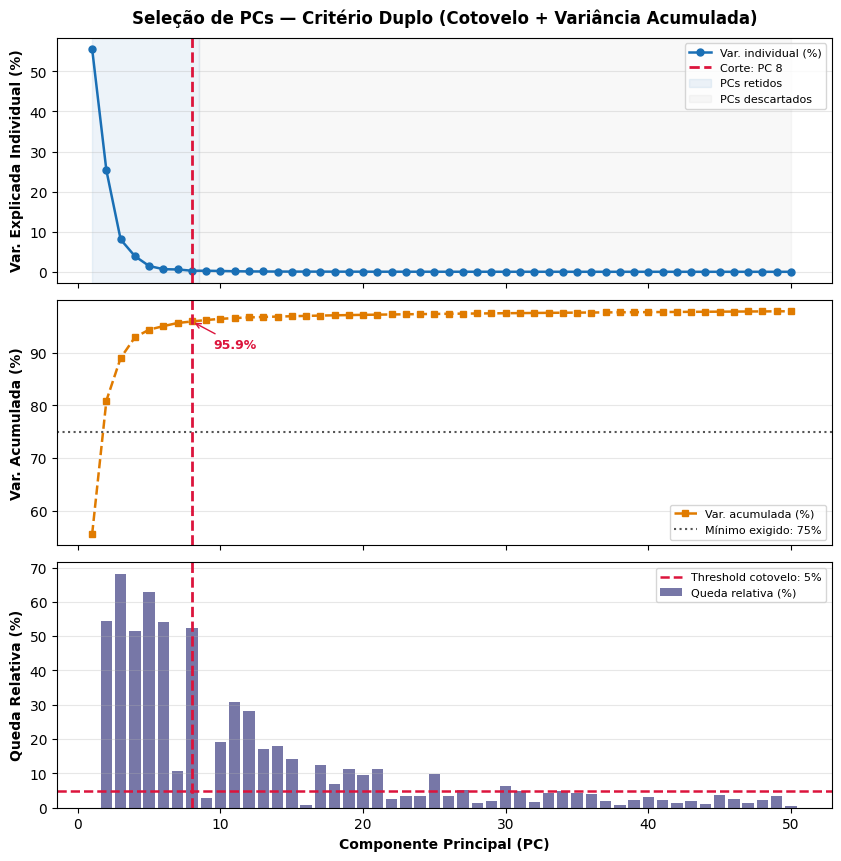


[PCA] Critério de corte : cotovelo (2.8% < 5%) + acumulada (95.9% ≥ 75%)
[PCA] PCs selecionados  : 8
[PCA] Variância capturada: 95.9%

[PCA] Recalculando PCA final com n_comps=8...


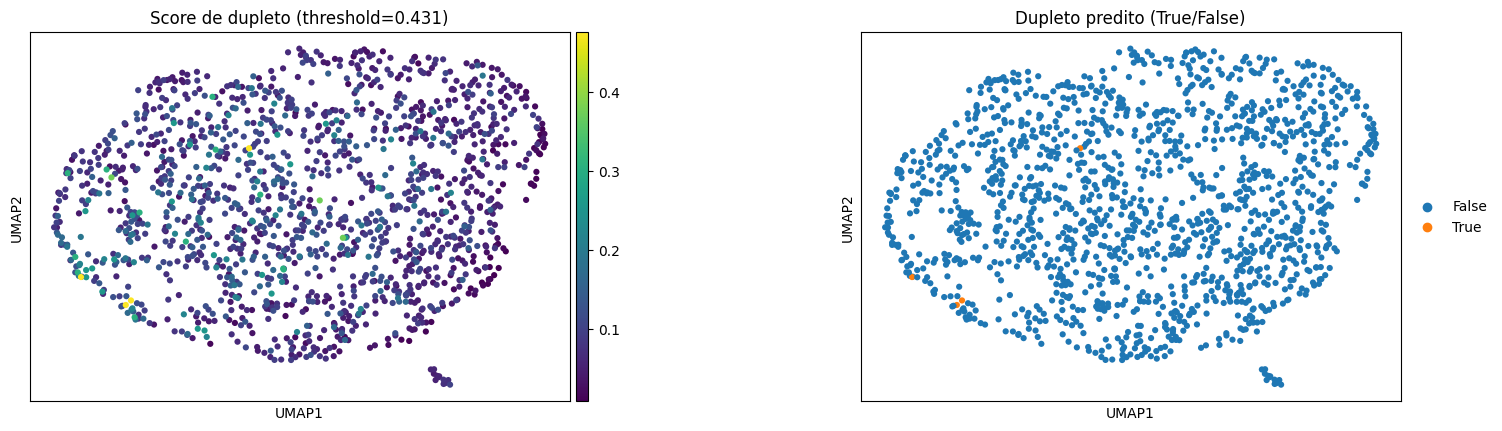


[Filtro] 4 dupletos removidos (0.3% das 1506 células).
[Filtro] 1502 células restantes.

  Amostra: HNP44_ML.h5ad
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.47
Detected doublet rate = 0.2%
Estimated detectable doublet fraction = 0.6%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 27.3%
Elapsed time: 1.7 seconds
Threshold automático do Scrublet : 0.468
Dupletos detectados              : 3 (0.2% das células)


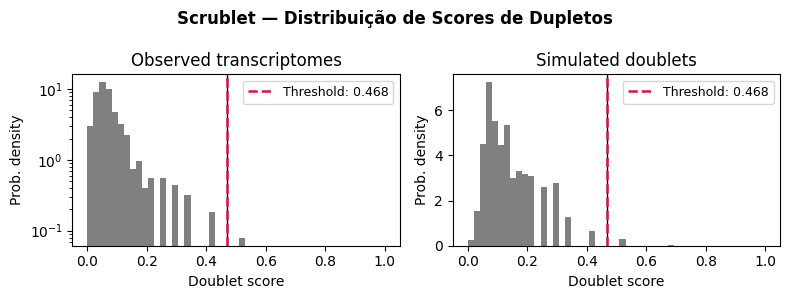

[PCA] Calculando PCA com n_comps=50...


/tmp/ipykernel_57614/2035270973.py:239: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


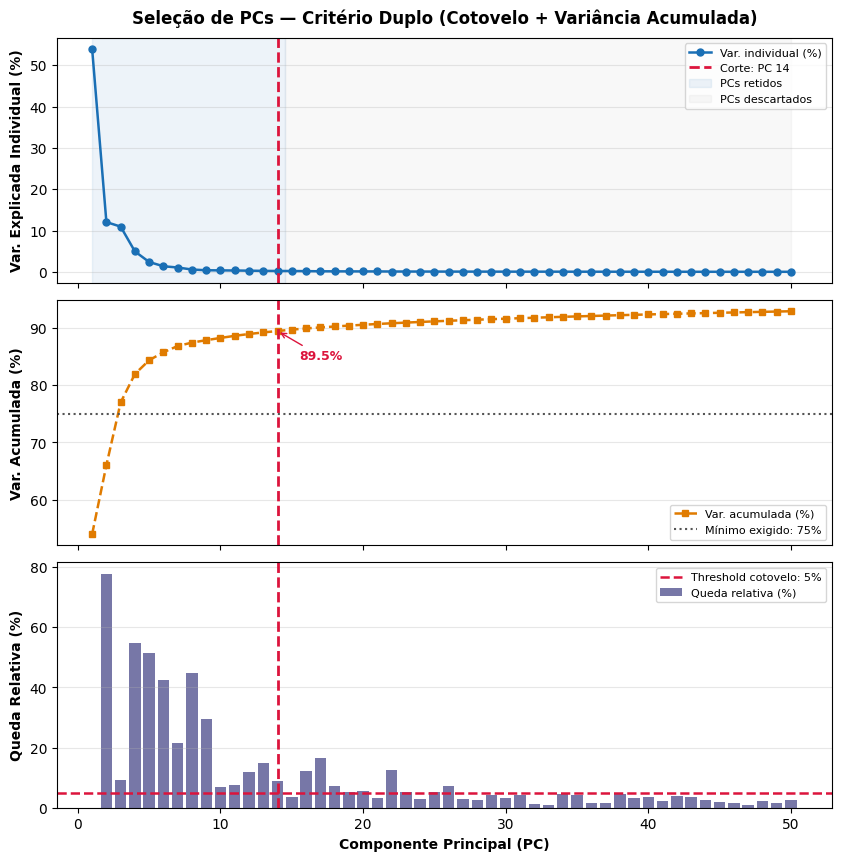


[PCA] Critério de corte : cotovelo (3.5% < 5%) + acumulada (89.5% ≥ 75%)
[PCA] PCs selecionados  : 14
[PCA] Variância capturada: 89.5%

[PCA] Recalculando PCA final com n_comps=14...


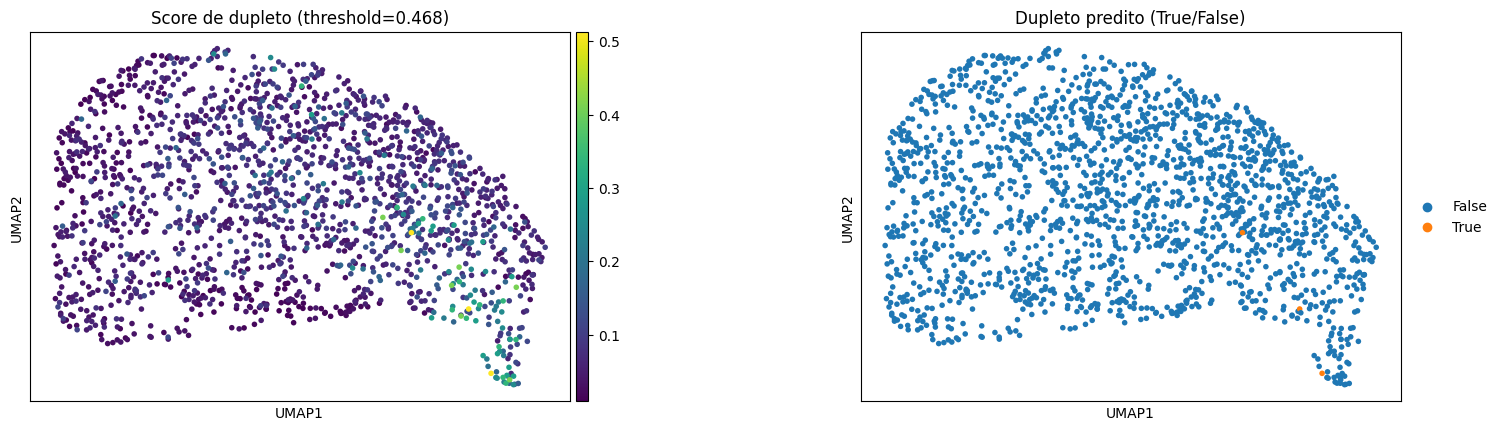


[Filtro] 3 dupletos removidos (0.2% das 1862 células).
[Filtro] 1859 células restantes.

  Amostra: HNP44_NS.h5ad
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.17
Detected doublet rate = 12.5%
Estimated detectable doublet fraction = 4.0%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 314.3%
Elapsed time: 0.1 seconds
Threshold automático do Scrublet : 0.167
Dupletos detectados              : 11 (12.5% das células)


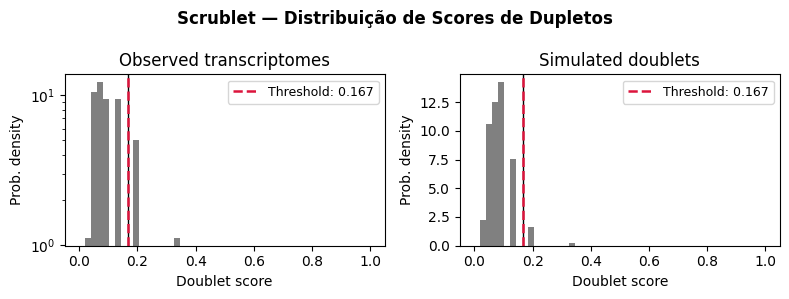

[PCA] Calculando PCA com n_comps=50...


/tmp/ipykernel_57614/2035270973.py:239: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


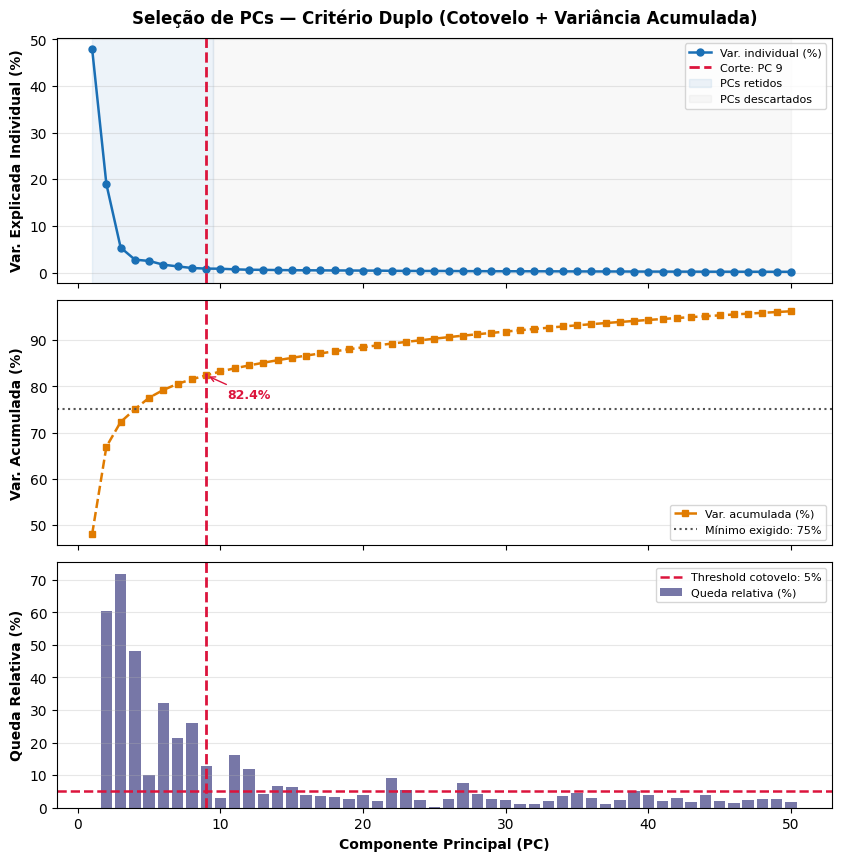


[PCA] Critério de corte : cotovelo (3.1% < 5%) + acumulada (82.4% ≥ 75%)
[PCA] PCs selecionados  : 9
[PCA] Variância capturada: 82.4%

[PCA] Recalculando PCA final com n_comps=9...


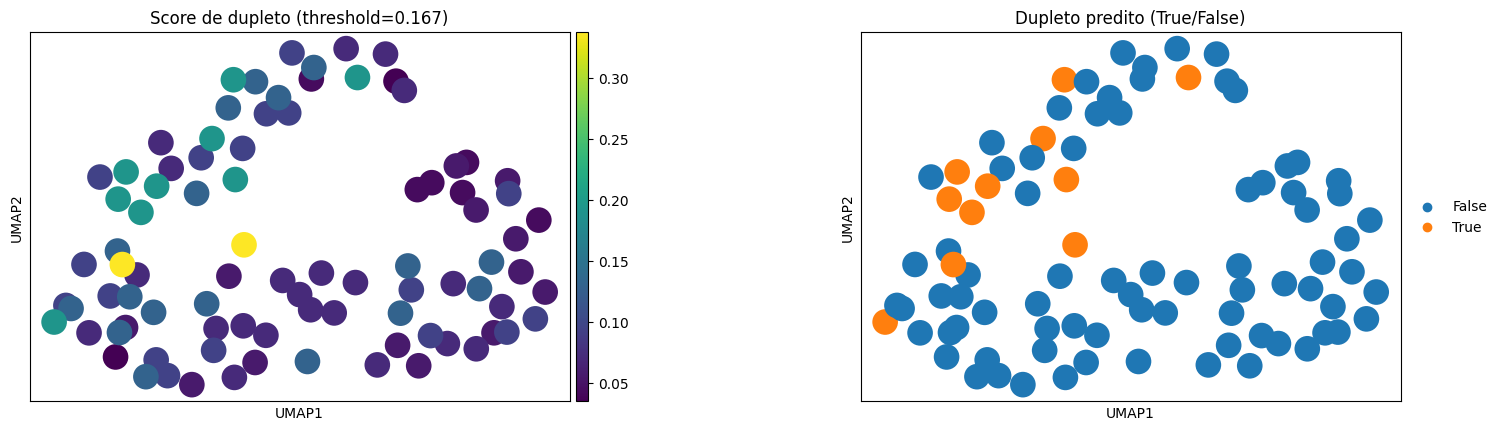


[Filtro] 11 dupletos removidos (12.5% das 88 células).
[Filtro] 77 células restantes.

  Amostra: MB34_ML.h5ad
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.38
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.5%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 0.0%
Elapsed time: 0.7 seconds
Threshold automático do Scrublet : 0.377
Dupletos detectados              : 0 (0.0% das células)


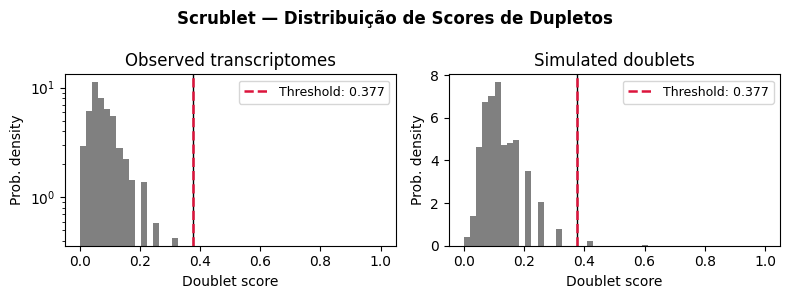

[PCA] Calculando PCA com n_comps=50...


/tmp/ipykernel_57614/2035270973.py:239: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


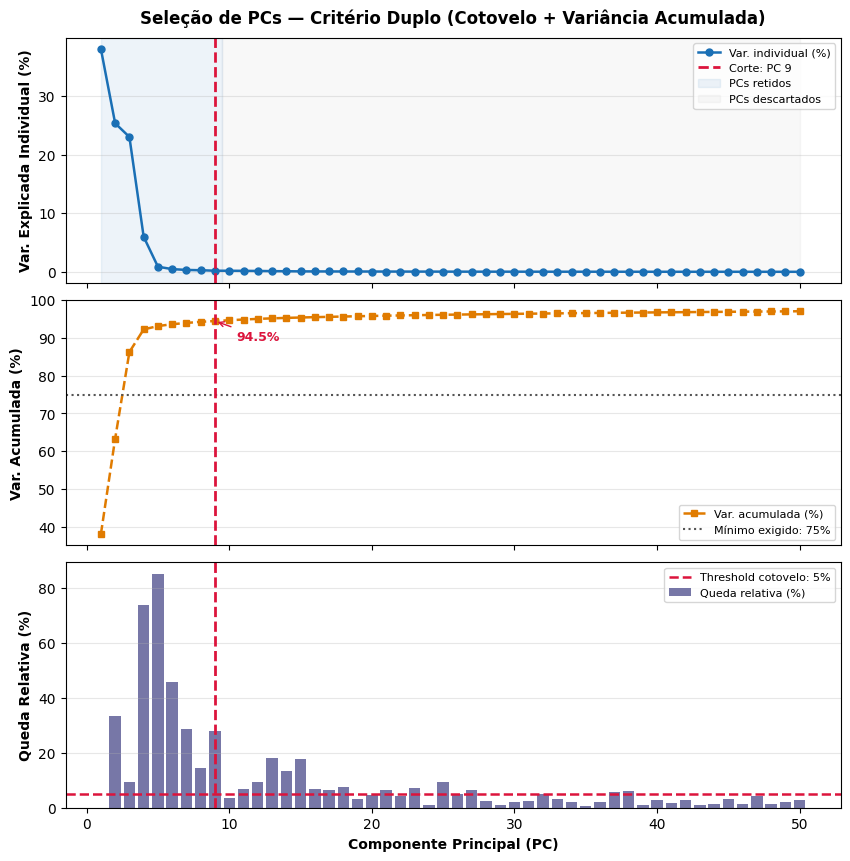


[PCA] Critério de corte : cotovelo (3.5% < 5%) + acumulada (94.5% ≥ 75%)
[PCA] PCs selecionados  : 9
[PCA] Variância capturada: 94.5%

[PCA] Recalculando PCA final com n_comps=9...


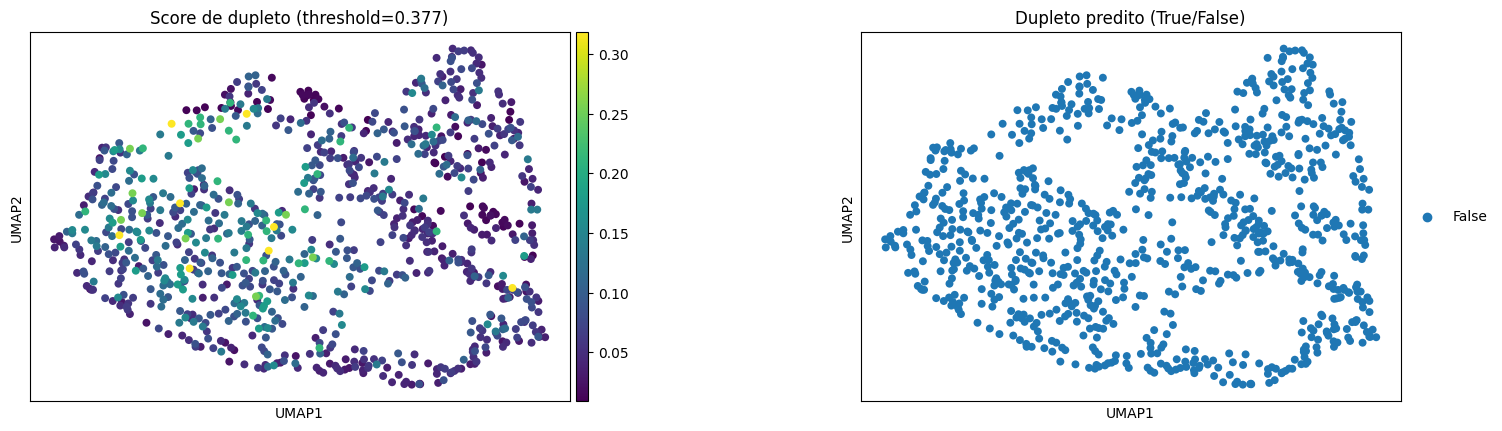


[Filtro] 0 dupletos removidos (0.0% das 921 células).
[Filtro] 921 células restantes.

  Amostra: MB34_NS.h5ad
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.46
Detected doublet rate = 0.3%
Estimated detectable doublet fraction = 4.6%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 5.7%
Elapsed time: 1.7 seconds
Threshold automático do Scrublet : 0.465
Dupletos detectados              : 5 (0.3% das células)


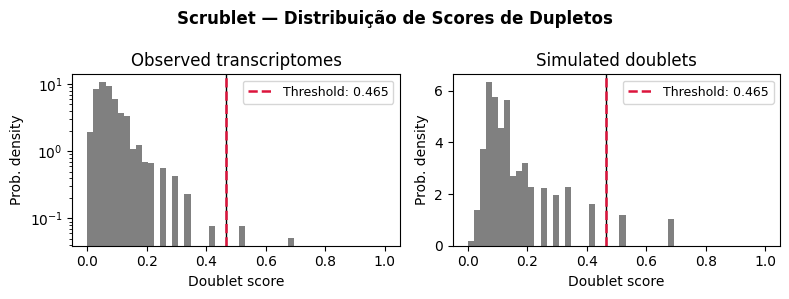

[PCA] Calculando PCA com n_comps=50...


/tmp/ipykernel_57614/2035270973.py:239: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


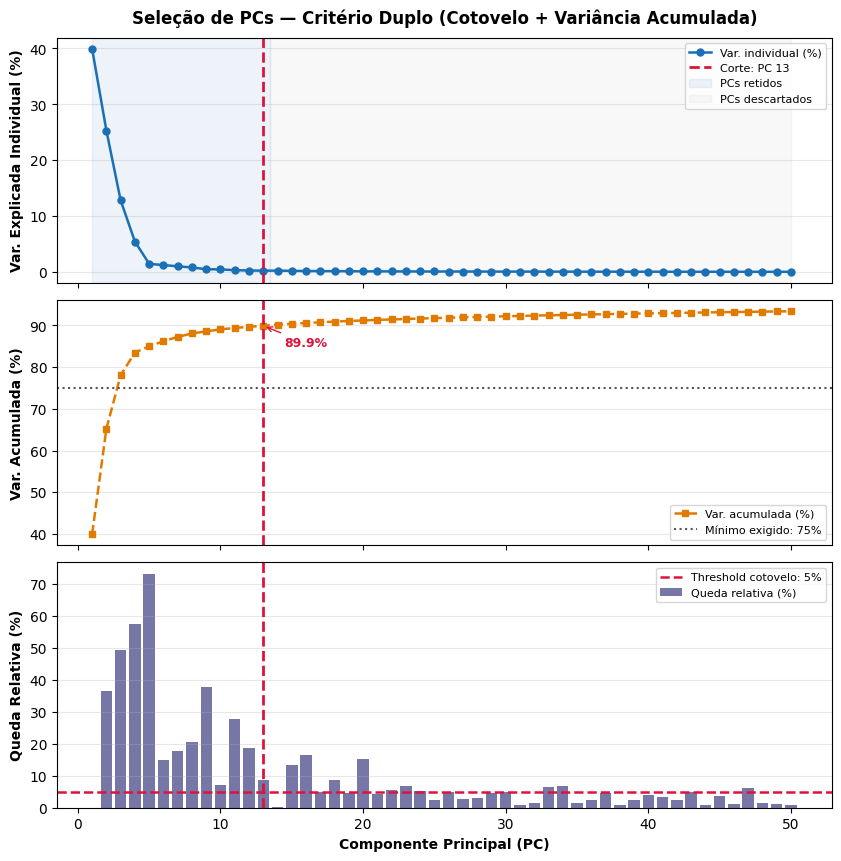


[PCA] Critério de corte : cotovelo (0.2% < 5%) + acumulada (89.9% ≥ 75%)
[PCA] PCs selecionados  : 13
[PCA] Variância capturada: 89.9%

[PCA] Recalculando PCA final com n_comps=13...


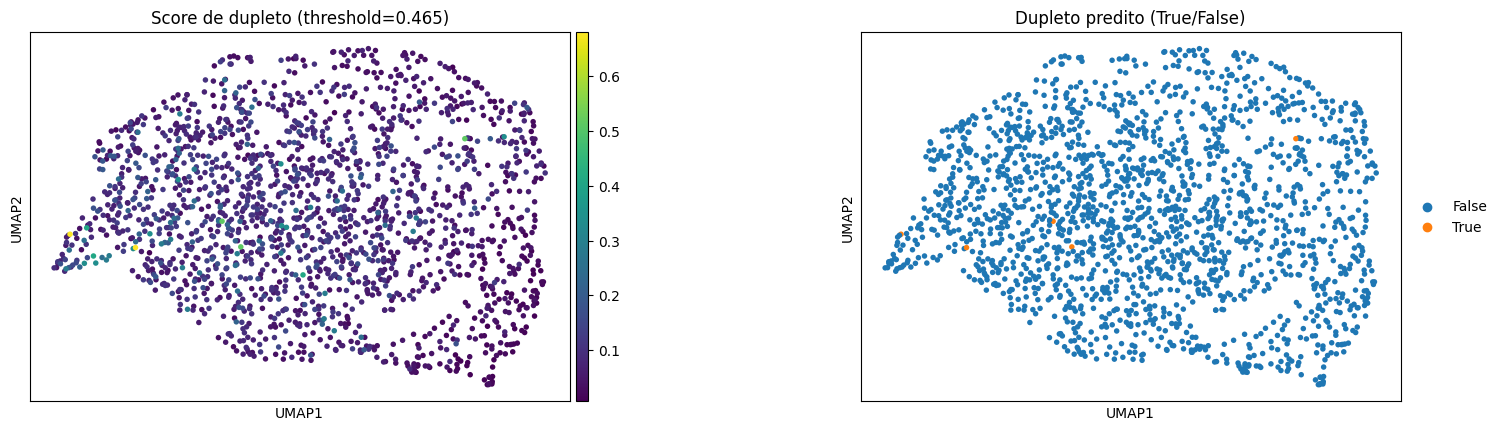


[Filtro] 5 dupletos removidos (0.3% das 1911 células).
[Filtro] 1906 células restantes.

  Amostra: PB20_ML.h5ad
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.36
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.9%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 0.0%
Elapsed time: 0.6 seconds
Threshold automático do Scrublet : 0.364
Dupletos detectados              : 0 (0.0% das células)


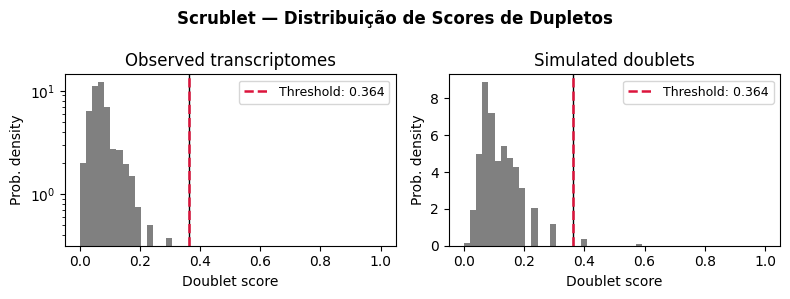

[PCA] Calculando PCA com n_comps=50...


/tmp/ipykernel_57614/2035270973.py:239: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


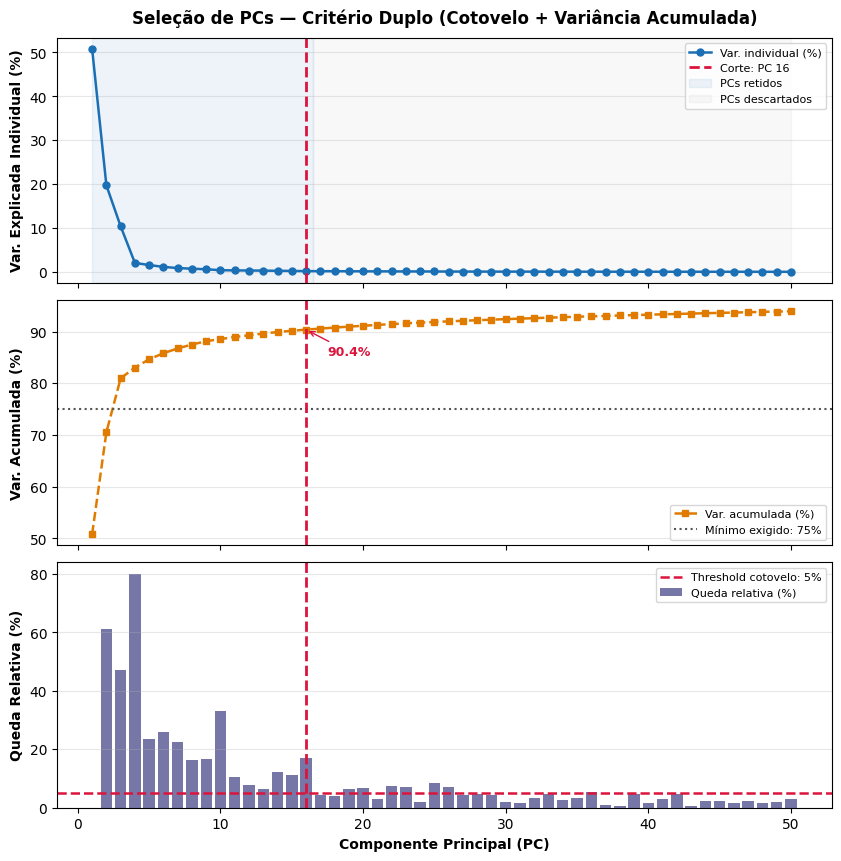


[PCA] Critério de corte : cotovelo (4.3% < 5%) + acumulada (90.4% ≥ 75%)
[PCA] PCs selecionados  : 16
[PCA] Variância capturada: 90.4%

[PCA] Recalculando PCA final com n_comps=16...


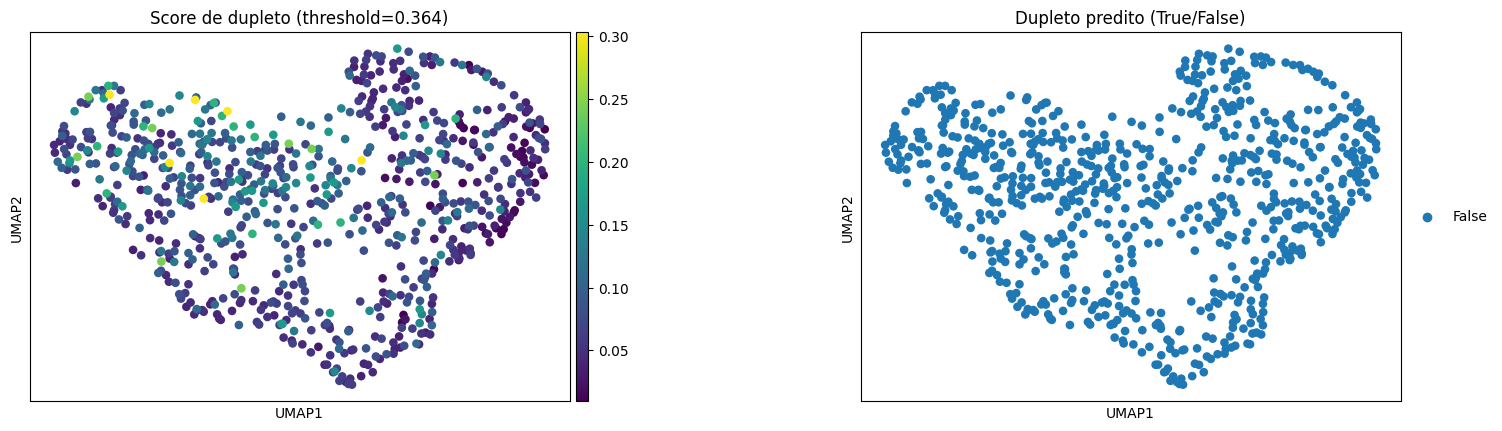


[Filtro] 0 dupletos removidos (0.0% das 777 células).
[Filtro] 777 células restantes.

  Amostra: PB20_NS.h5ad
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.33
Detected doublet rate = 0.3%
Estimated detectable doublet fraction = 1.8%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 18.2%
Elapsed time: 0.4 seconds
Threshold automático do Scrublet : 0.326
Dupletos detectados              : 2 (0.3% das células)


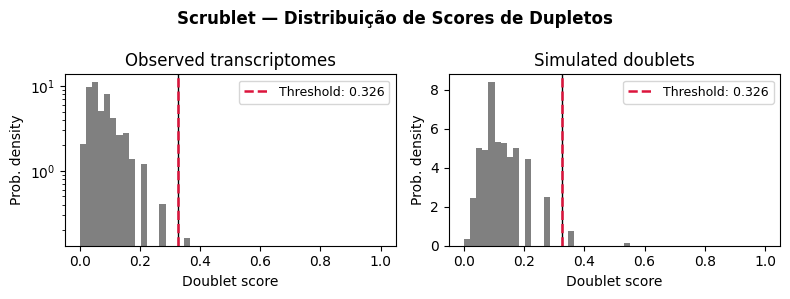

[PCA] Calculando PCA com n_comps=50...


/tmp/ipykernel_57614/2035270973.py:239: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


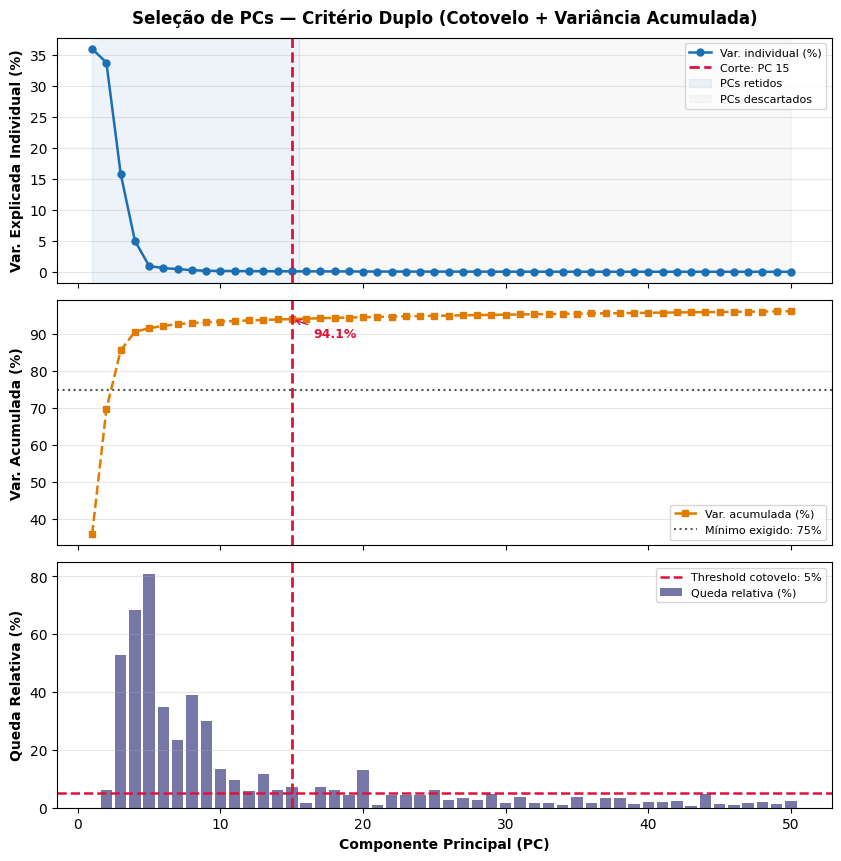


[PCA] Critério de corte : cotovelo (1.6% < 5%) + acumulada (94.1% ≥ 75%)
[PCA] PCs selecionados  : 15
[PCA] Variância capturada: 94.1%

[PCA] Recalculando PCA final com n_comps=15...


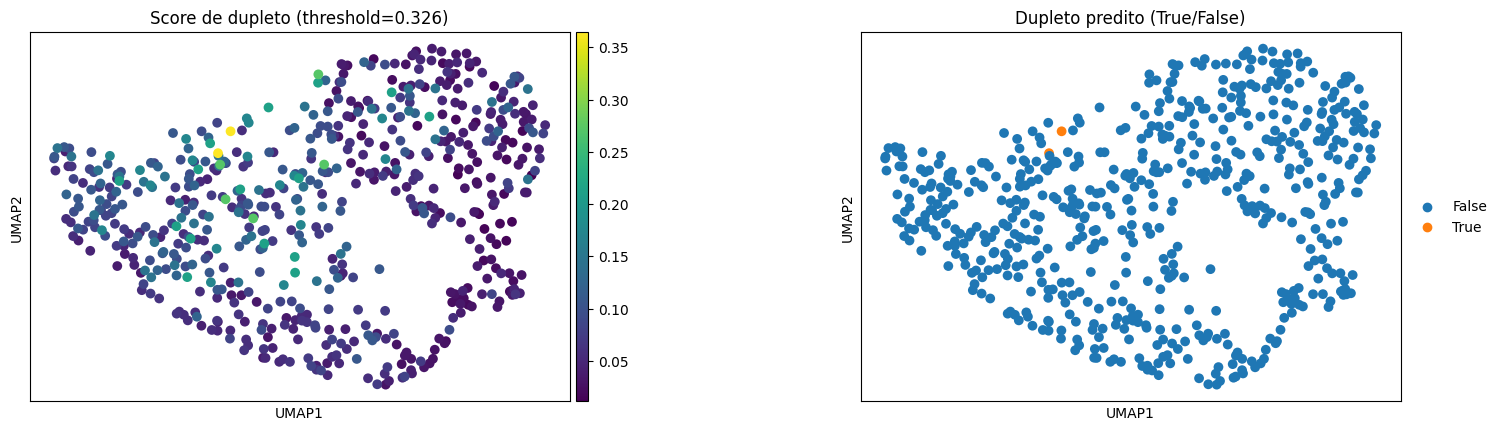


[Filtro] 2 dupletos removidos (0.3% das 606 células).
[Filtro] 604 células restantes.

  Amostra: PB21_ML.h5ad
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.60
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.1%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 22.2%
Elapsed time: 9.0 seconds
Threshold automático do Scrublet : 0.597
Dupletos detectados              : 2 (0.0% das células)


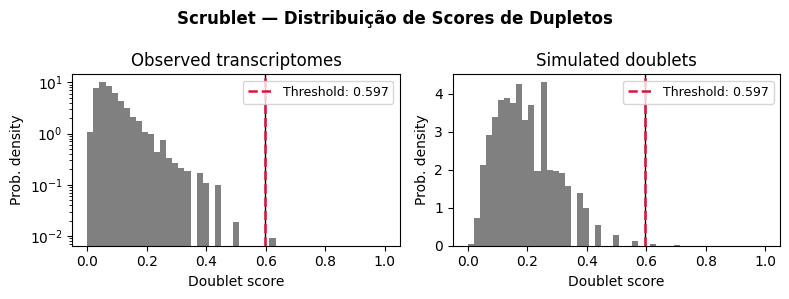

[PCA] Calculando PCA com n_comps=50...


/tmp/ipykernel_57614/2035270973.py:239: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


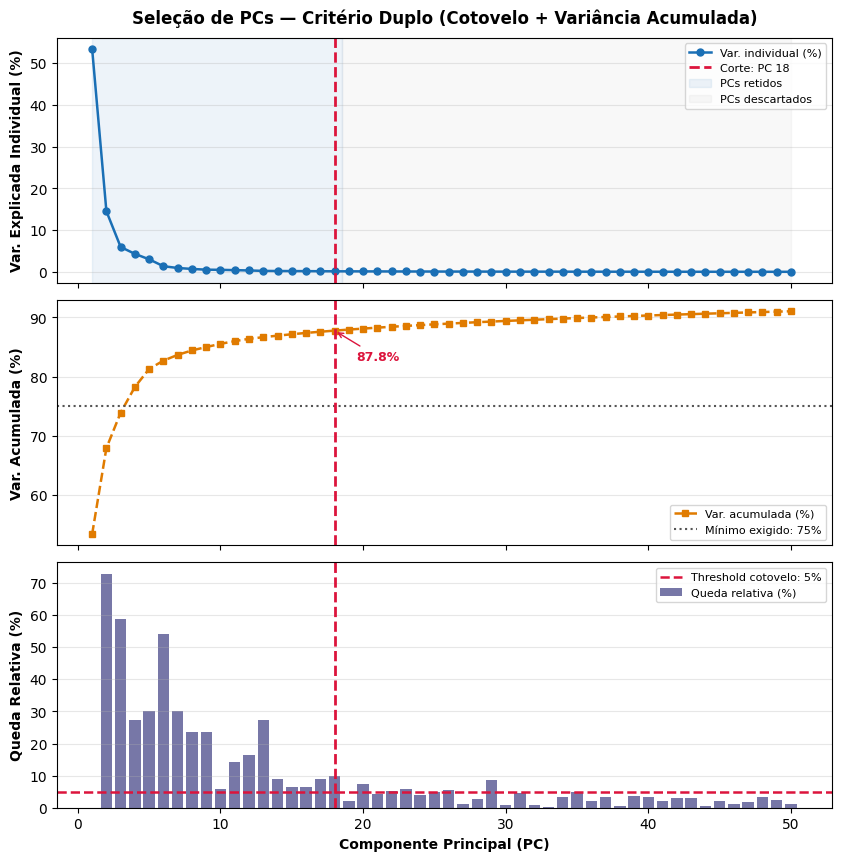


[PCA] Critério de corte : cotovelo (2.0% < 5%) + acumulada (87.8% ≥ 75%)
[PCA] PCs selecionados  : 18
[PCA] Variância capturada: 87.8%

[PCA] Recalculando PCA final com n_comps=18...


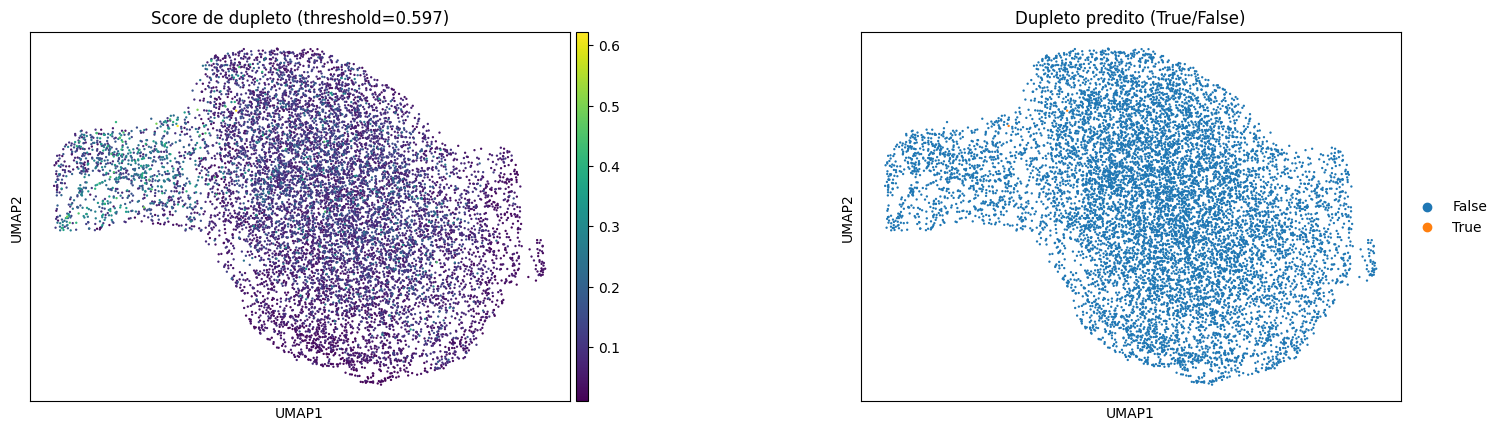


[Filtro] 2 dupletos removidos (0.0% das 10619 células).
[Filtro] 10617 células restantes.

  Amostra: PB21_NS.h5ad
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.55
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.5%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 5.3%
Elapsed time: 2.8 seconds
Threshold automático do Scrublet : 0.553
Dupletos detectados              : 1 (0.0% das células)


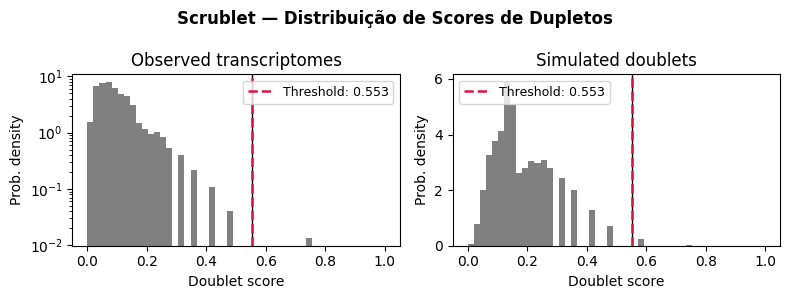

[PCA] Calculando PCA com n_comps=50...


/tmp/ipykernel_57614/2035270973.py:239: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


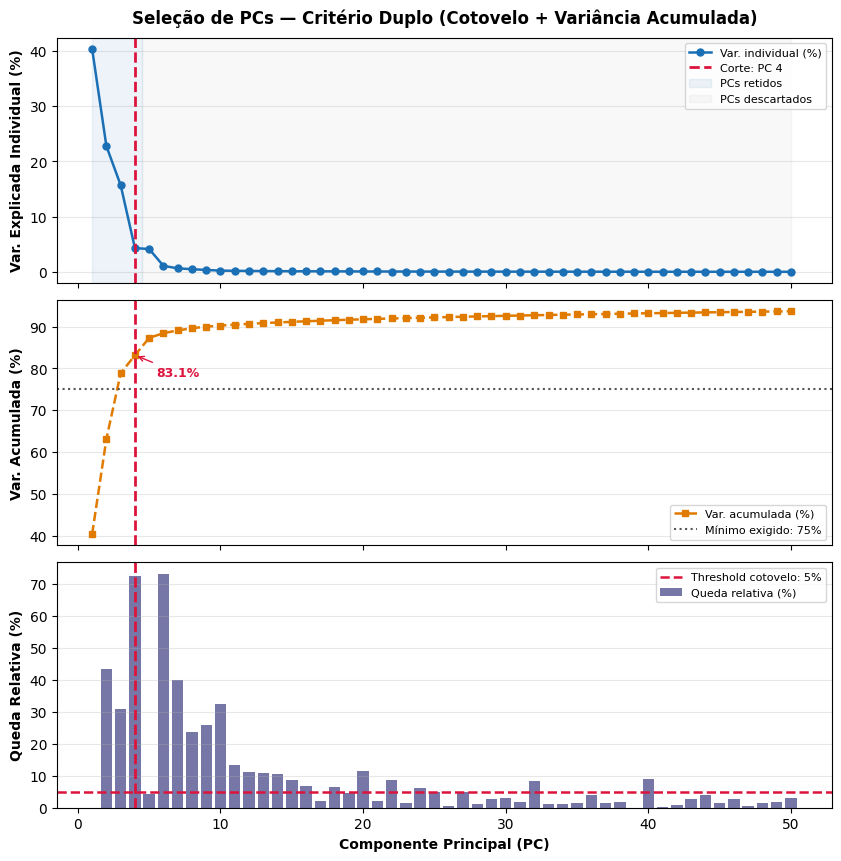


[PCA] Critério de corte : cotovelo (4.1% < 5%) + acumulada (83.1% ≥ 75%)
[PCA] PCs selecionados  : 4
[PCA] Variância capturada: 83.1%

[PCA] Recalculando PCA final com n_comps=4...


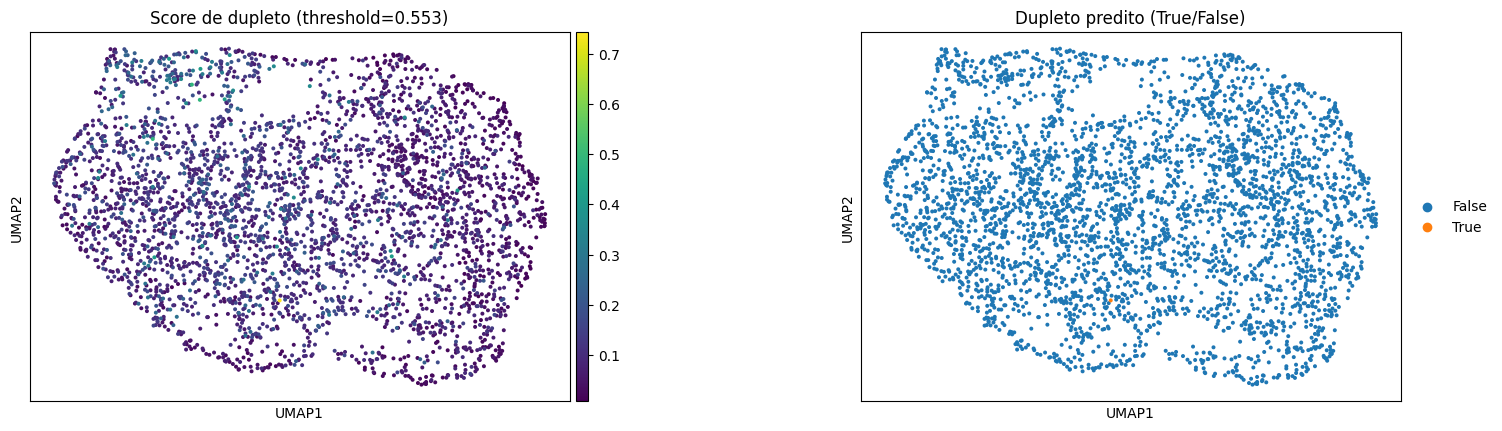


[Filtro] 1 dupletos removidos (0.0% das 3626 células).
[Filtro] 3625 células restantes.


In [5]:
"""
Pipeline: Scrublet + PCA para single-cell RNA-seq
==================================================
Critérios de design:
  - Biologicamente correto: PC selection usa critério DUPLO (cotovelo + mínimo de
    variância acumulada), garantindo que subpopulações raras não sejam perdidas.
  - Matematicamente correto: sem divisão por zero, sem recálculo desnecessário de PCA.
  - Visualmente claro: plot de cotovelo com anotações, regiões coloridas e legenda útil.
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scrublet as scr
import scanpy as sc
import numpy as np


# ─────────────────────────────────────────────
# 1. SCRUBLET
# ─────────────────────────────────────────────

def run_scrublet(adata, expected_doublet_rate=0.06):
    """
    Detecta dupletos com Scrublet e anota o AnnData.
    """
    scrub = scr.Scrublet(adata.X, expected_doublet_rate=expected_doublet_rate)
    scores, predicted = scrub.scrub_doublets()

    adata.obs["doublet_score"]     = scores
    adata.obs["predicted_doublet"] = predicted

    print(f"Threshold automático do Scrublet : {scrub.threshold_:.3f}")
    print(f"Dupletos detectados              : {predicted.sum()} "
          f"({predicted.mean()*100:.1f}% das células)")

    return adata, scrub


def plot_scrublet_histogram(scrub, threshold_override=None):
    """
    Histograma de scores observados vs. simulados,
    com linha de threshold (automático ou manual).
    """
    fig, axes = scrub.plot_histogram()          # retorna (fig, axes) no Scrublet ≥0.2.3

    thr = threshold_override if threshold_override is not None else scrub.threshold_
    for ax in axes:
        ax.axvline(thr, color="crimson", linestyle="--", linewidth=1.8,
                   label=f"Threshold: {thr:.3f}")
        ax.legend(fontsize=9)

    fig.suptitle("Scrublet — Distribuição de Scores de Dupletos", fontweight="bold")
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────
# 2. SELEÇÃO DE PCs  (o núcleo corrigido)
# ─────────────────────────────────────────────

def choose_pcs_elbow(
    adata,
    max_pcs: int   = 50,
    rel_threshold: float = 0.05,
    cum_var_min:   float = 0.75,
    interactive:   bool  = False,
) -> int:
    """
    Seleciona o número ótimo de PCs usando critério DUPLO:

        1. Cotovelo (elbow): taxa de queda relativa da variância < rel_threshold.
        2. Variância acumulada mínima: garante que ≥ cum_var_min foi capturada.

    O ponto de corte SÓ é aceito quando AMBAS as condições são satisfeitas.
    Isso evita o erro clássico de cortar cedo demais e perder subpopulações raras.

    Parameters
    ----------
    adata          : AnnData com dados normalizados/log-transformados.
    max_pcs        : número máximo de PCs a calcular/avaliar.
    rel_threshold  : mudança relativa mínima para considerar a curva "plana" (padrão 5%).
    cum_var_min    : variância acumulada mínima exigida antes de aceitar o corte (padrão 75%).
    interactive    : se True, permite ao usuário sobrescrever a escolha manualmente.

    Returns
    -------
    int : número de PCs selecionados.
    """

    # ── Calcula PCA apenas se necessário ──────────────────────────────────────
    pca_ok = (
        "pca" in adata.uns
        and "variance_ratio" in adata.uns["pca"]
        and adata.uns["pca"]["variance_ratio"].shape[0] >= max_pcs
    )
    if not pca_ok:
        print(f"[PCA] Calculando PCA com n_comps={max_pcs}...")
        sc.pp.pca(adata, n_comps=max_pcs)

    var_ratio = adata.uns["pca"]["variance_ratio"][:max_pcs]   # shape (max_pcs,)
    cum_var   = np.cumsum(var_ratio)

    # ── Cotovelo: taxa de queda relativa ──────────────────────────────────────
    # diff[i]  = |var[i] - var[i+1]|          (quanto caiu)
    # rel[i]   = diff[i] / var[i]             (queda relativa em relação ao PC anterior)
    # epsilon evita divisão por zero em PCs de variância quase nula
    diff       = np.abs(np.diff(var_ratio))
    rel_change = diff / (var_ratio[:-1] + 1e-9)

    # ── Critério DUPLO ────────────────────────────────────────────────────────
    # Só aceita o corte se:
    #   (a) a queda relativa estabilizou (< rel_threshold)
    #   (b) a variância acumulada já atingiu a meta (>= cum_var_min)
    # Se nenhum PC satisfizer (a) + (b), usa max_pcs como fallback seguro.
    pcs_selected = max_pcs
    cutoff_reason = "fallback (max_pcs)"

    for i, (rel, cum) in enumerate(zip(rel_change, cum_var[:-1])):
        elbow_ok  = rel < rel_threshold
        cum_ok    = cum >= cum_var_min
        if elbow_ok and cum_ok:
            pcs_selected  = i + 1       # i é índice 0-based do diff → PC = i+1
            cutoff_reason = (
                f"cotovelo ({rel*100:.1f}% < {rel_threshold*100:.0f}%) "
                f"+ acumulada ({cum*100:.1f}% ≥ {cum_var_min*100:.0f}%)"
            )
            break
        elif elbow_ok and not cum_ok:
            # Cotovelo encontrado mas variância acumulada ainda insuficiente:
            # avisa o usuário mas continua procurando
            print(f"[PCA] PC {i+1}: cotovelo detectado mas variância acumulada "
                  f"({cum*100:.1f}%) < mínimo ({cum_var_min*100:.0f}%). Continuando...")

    # ── Plot ──────────────────────────────────────────────────────────────────
    _plot_elbow(
        var_ratio    = var_ratio,
        cum_var      = cum_var,
        rel_change   = rel_change,
        pcs_selected = pcs_selected,
        rel_threshold= rel_threshold,
        cum_var_min  = cum_var_min,
    )

    print(f"\n[PCA] Critério de corte : {cutoff_reason}")
    print(f"[PCA] PCs selecionados  : {pcs_selected}")
    print(f"[PCA] Variância capturada: {cum_var[pcs_selected-1]*100:.1f}%")

    # ── Override manual ───────────────────────────────────────────────────────
    if interactive:
        resposta = input(
            f"\nO algoritmo sugeriu {pcs_selected} PCs. Deseja alterar? [s/N]: "
        ).lower().strip()
        if resposta in ("s", "sim"):
            while True:
                try:
                    manual = int(input(f"Número de PCs (1–{max_pcs}): "))
                    if 1 <= manual <= max_pcs:
                        pcs_selected = manual
                        break
                    print(f"Escolha um número entre 1 e {max_pcs}.")
                except ValueError:
                    print("Digite apenas um inteiro.")

    return pcs_selected


def _plot_elbow(var_ratio, cum_var, rel_change, pcs_selected,
                rel_threshold, cum_var_min):
    """
    Plot de cotovelo com três painéis:
      1. Variância individual + linha de corte
      2. Variância acumulada + meta mínima
      3. Taxa de queda relativa + threshold do cotovelo
    """
    n = len(var_ratio)
    pcs = np.arange(1, n + 1)

    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True,
                             gridspec_kw={"hspace": 0.07})

    # ── Painel 1: Variância Individual ────────────────────────────────────────
    ax1 = axes[0]
    ax1.plot(pcs, var_ratio * 100, "o-", color="#1a6fb5", linewidth=1.8,
             markersize=5, label="Var. individual (%)")
    ax1.axvline(pcs_selected, color="crimson", linestyle="--", linewidth=2.0,
                label=f"Corte: PC {pcs_selected}")
    # Sombreamento: PCs aceitos vs. descartados
    ax1.axvspan(1, pcs_selected + 0.5, alpha=0.08, color="#1a6fb5", label="PCs retidos")
    ax1.axvspan(pcs_selected + 0.5, n, alpha=0.05, color="gray",   label="PCs descartados")
    ax1.set_ylabel("Var. Explicada Individual (%)", fontweight="bold")
    ax1.legend(fontsize=8, loc="upper right")
    ax1.set_title("Seleção de PCs — Critério Duplo (Cotovelo + Variância Acumulada)",
                  fontsize=12, fontweight="bold", pad=10)
    ax1.grid(axis="y", alpha=0.3)

    # ── Painel 2: Variância Acumulada ─────────────────────────────────────────
    ax2 = axes[1]
    ax2.plot(pcs, cum_var * 100, "s--", color="#e07b00", linewidth=1.8,
             markersize=5, label="Var. acumulada (%)")
    ax2.axhline(cum_var_min * 100, color="#555", linestyle=":", linewidth=1.5,
                label=f"Mínimo exigido: {cum_var_min*100:.0f}%")
    ax2.axvline(pcs_selected, color="crimson", linestyle="--", linewidth=2.0)
    # Anotação do valor no ponto de corte
    val_at_cut = cum_var[pcs_selected - 1] * 100
    ax2.annotate(
        f"{val_at_cut:.1f}%",
        xy=(pcs_selected, val_at_cut),
        xytext=(pcs_selected + 1.5, val_at_cut - 5),
        arrowprops=dict(arrowstyle="->", color="crimson"),
        fontsize=9, color="crimson", fontweight="bold"
    )
    ax2.set_ylabel("Var. Acumulada (%)", fontweight="bold")
    ax2.legend(fontsize=8, loc="lower right")
    ax2.grid(axis="y", alpha=0.3)

    # ── Painel 3: Taxa de Queda Relativa (cotovelo) ───────────────────────────
    ax3 = axes[2]
    # rel_change tem n-1 valores; representa a transição do PC i para i+1
    # plotamos no eixo do PC de destino (i+1 → pcs[1:])
    ax3.bar(pcs[1:], rel_change * 100, color="#4a4a8a", alpha=0.75,
            label="Queda relativa (%)")
    ax3.axhline(rel_threshold * 100, color="crimson", linestyle="--", linewidth=1.8,
                label=f"Threshold cotovelo: {rel_threshold*100:.0f}%")
    ax3.axvline(pcs_selected, color="crimson", linestyle="--", linewidth=2.0)

    # Destaca a região onde o critério duplo NÃO foi satisfeito por falta de
    # variância acumulada (cotovelo ok mas acumulada insuficiente)
    for i, (rel, cum) in enumerate(zip(rel_change, cum_var[:-1])):
        if rel < rel_threshold and cum < cum_var_min:
            ax3.axvspan(pcs[i+1] - 0.5, pcs[i+1] + 0.5,
                        alpha=0.3, color="orange",
                        label="Cotovelo sem acumulada suficiente" if i == 0 else "")

    ax3.set_ylabel("Queda Relativa (%)", fontweight="bold")
    ax3.set_xlabel("Componente Principal (PC)", fontweight="bold")
    ax3.legend(fontsize=8, loc="upper right")
    ax3.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────
# 3. PIPELINE COMPLETO (sem PCA duplicado)
# ─────────────────────────────────────────────

def scrublet_full_pipeline(adata, max_pcs=50, interactive=False):
    """
    Pipeline completo: Scrublet → seleção de PCs → UMAP anotado.

    Correções em relação à versão original:
      - PCA não é recalculado duas vezes.
      - `choose_pcs_elbow` usa o critério duplo (cotovelo + acumulada ≥ 75%).
      - UMAP é construído sobre o PCA otimizado, não sobre o padrão.
      - Células detectadas como dupletos ficam visíveis no UMAP antes da filtragem.
    """

    # 1. Detecção de dupletos ─────────────────────────────────────────────────
    adata, scrub = run_scrublet(adata)
    plot_scrublet_histogram(scrub)

    # 2. Seleção de PCs (já calcula o PCA internamente se necessário) ──────────
    pcs_selected = choose_pcs_elbow(
        adata,
        max_pcs=max_pcs,
        interactive=interactive,
    )

    # 3. Re-roda PCA com o número ótimo de PCs ────────────────────────────────
    # Necessário porque choose_pcs_elbow pode ter usado max_pcs para o plot;
    # agora gravamos apenas os pcs_selected no adata.obsm["X_pca"] usado a seguir.
    print(f"\n[PCA] Recalculando PCA final com n_comps={pcs_selected}...")
    sc.pp.pca(adata, n_comps=pcs_selected)

    # 4. Grafo de vizinhos + UMAP ─────────────────────────────────────────────
    sc.pp.neighbors(adata, n_pcs=pcs_selected)
    sc.tl.umap(adata)

    # 5. Visualização dos dupletos no espaço UMAP ─────────────────────────────
    sc.pl.umap(
        adata,
        color=["doublet_score", "predicted_doublet"],
        wspace=0.4,
        title=[
            f"Score de dupleto (threshold={scrub.threshold_:.3f})",
            "Dupleto predito (True/False)",
        ],
    )

    # 6. Filtragem opcional: remove dupletos antes de retornar ─────────────────
    n_before = adata.n_obs
    adata_clean = adata[~adata.obs["predicted_doublet"]].copy()
    n_removed = n_before - adata_clean.n_obs
    print(f"\n[Filtro] {n_removed} dupletos removidos "
          f"({n_removed/n_before*100:.1f}% das {n_before} células).")
    print(f"[Filtro] {adata_clean.n_obs} células restantes.")

    return adata_clean, scrub

# ─────────────────────────────────────────────
# 4. LOOP POR AMOSTRA
# ─────────────────────────────────────────────

# Exemplo de uso (substitua `adatas` e `pastas` pelas suas variáveis):
#
adatas_clean = []
for i, adata in enumerate(adatas):
    print(f"\n{'='*50}")
    print(f"  Amostra: {pastas[i]}")
    print(f"{'='*50}")
    adata_clean, scrub = scrublet_full_pipeline(adata)
    adatas_clean.append(adata_clean)

In [28]:
[i.n_obs for i in adatas_clean]

[1523, 809, 496, 5558, 4657, 1502, 1859, 77, 921, 1906, 777, 604, 10617, 3625]

In [31]:
adatas_clean[0].write_h5ad("/mnt/SATA/singleCellTaru/data/new/data.h5ad")

In [41]:
for i, (adata, pasta) in enumerate(zip(adatas_clean, pastas)):
    print(f"{i} -> {pasta} | células: {adata.n_obs}")

0 -> CTH92_ML.h5ad | células: 1523
1 -> CTH92_NS.h5ad | células: 809
2 -> CTH94_ML.h5ad | células: 496
3 -> CTH94_NS.h5ad | células: 5558
4 -> CTH97_ML.h5ad | células: 4657
5 -> CTH97_NS.h5ad | células: 1502
6 -> HNP44_ML.h5ad | células: 1859
7 -> HNP44_NS.h5ad | células: 77
8 -> MB34_ML.h5ad | células: 921
9 -> MB34_NS.h5ad | células: 1906
10 -> PB20_ML.h5ad | células: 777
11 -> PB20_NS.h5ad | células: 604
12 -> PB21_ML.h5ad | células: 10617
13 -> PB21_NS.h5ad | células: 3625


In [42]:
output_dir = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), "data", "new")

# DOUBLET detection with scrublet
for i, (adata, pasta) in enumerate(zip(adatas_clean, pastas)):
    print(f"{i} -> {pasta} | células: {adata.n_obs}")

    if pasta.endswith(".h5ad"):
        output_file_path = os.path.join(output_dir, pasta)
    else:
        output_file_path = os.path.join(output_dir, f"{pasta}.h5ad")

    sc.write(output_file_path, adata)  # type: ignore

0 -> CTH92_ML.h5ad | células: 1523
1 -> CTH92_NS.h5ad | células: 809
2 -> CTH94_ML.h5ad | células: 496
3 -> CTH94_NS.h5ad | células: 5558
4 -> CTH97_ML.h5ad | células: 4657
5 -> CTH97_NS.h5ad | células: 1502
6 -> HNP44_ML.h5ad | células: 1859
7 -> HNP44_NS.h5ad | células: 77
8 -> MB34_ML.h5ad | células: 921
9 -> MB34_NS.h5ad | células: 1906
10 -> PB20_ML.h5ad | células: 777
11 -> PB20_NS.h5ad | células: 604
12 -> PB21_ML.h5ad | células: 10617
13 -> PB21_NS.h5ad | células: 3625


In [ ]:
# =============================================================
# 4. Salvar (padronizado com seu código)
# =============================================================
for adata, pasta in zip(adata_clean, pastas):

    if pasta.endswith(".h5ad"):
        output_file_path = os.path.join(output_dir, pasta)
    else:
        output_file_path = os.path.join(output_dir, f"{pasta}.h5ad")

    sc.write(output_file_path, adata)  # type: ignore

print("✅ Tudo concluído e salvo em:", output_dir)

In [20]:
print(f"Total antes: {sum([adata.n_obs for adata in adatas])}, Total depois: {sum([adata.n_obs for adata in adatas_clean])}")
print(f"Corte: {sum([adata.n_obs for adata in adatas]) - sum([adata.n_obs for adata in adatas_clean])}")

Total antes: 34969, Total depois: 34931
Corte: 38
